# **Analisis & Prediksi Pembatalan Booking Hotel (CRISP-DM)**

Notebook ini menganalisis dataset `hotel_booking.csv` dan membangun model klasifikasi untuk memprediksi
apakah sebuah booking akan dibatalkan (`is_canceled`). Alur kerja mengikuti kerangka **CRISP-DM**:

1. **Business Understanding**: memahami masalah bisnis dan tujuan analisis
2. **Data Understanding**: mengenali struktur, tipe, dan kualitas data
3. **Data Preparation**: data wrangling dan feature engineering
4. **Exploratory Data Analysis (EDA)**: pola, tren, dan hubungan antar variabel
5. **Hypothesis Testing**: validasi temuan EDA secara statistik
6. **Modeling**: baseline model (Logistic Regression, Random Forest, XGBoost), cross-validation, dan hyperparameter tuning
7. **Evaluation**: perbandingan performa model pada data uji
8. **Deployment**: menyimpan pipeline model dan fungsi prediksi

# **Libraries**

In [1]:
import time
import warnings
import joblib

import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

# **1. Business Understanding**

**Latar belakang.** Pembatalan booking adalah salah satu sumber kerugian terbesar bagi hotel. Kamar yang
sudah "terjual" lalu dibatalkan mendekati tanggal kedatangan sering kali tidak sempat dijual ulang,
sehingga pendapatan hilang dan perencanaan operasional (staf, stok, harga) menjadi tidak akurat.

**Tujuan bisnis.**
- Memahami faktor apa saja yang berkaitan dengan pembatalan booking.
- Membangun model yang dapat memprediksi probabilitas pembatalan sejak booking dibuat, agar hotel bisa
  mengambil tindakan pencegahan (misalnya kebijakan deposit, reminder, atau overbooking yang terukur).

**Tujuan analitik.**
- Target: `is_canceled` (1 = dibatalkan, 0 = tidak dibatalkan). Ini adalah masalah **klasifikasi biner**.
- Model yang dibandingkan: **Logistic Regression**, **Random Forest**, dan **XGBoost**.
- Metrik utama: **ROC-AUC** (kemampuan membedakan kelas) dan **F1-score** (keseimbangan precision dan recall
  untuk kelas "batal"). Recall kelas batal penting karena pembatalan yang tidak terdeteksi berarti
  kamar kosong yang tidak diantisipasi.

# **2. Data Understanding**

## Data Loading

In [2]:
df = pd.read_csv('hotel_booking.csv')
print(f"Dimensi dataset: {df.shape[0]:,} baris x {df.shape[1]} kolom")
df.head()

Dimensi dataset: 119,390 baris x 36 kolom


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


**Distribusi target `is_canceled`**

Sebelum masuk ke preparation, kita lihat dulu proporsi kelas target untuk mengetahui apakah data
imbalanced atau tidak.

In [5]:
target_dist = df['is_canceled'].value_counts().rename({0: 'Tidak Batal', 1: 'Batal'})
print(target_dist)
print()
print((target_dist / target_dist.sum() * 100).round(2).astype(str) + ' %')

is_canceled
Tidak Batal    75166
Batal          44224
Name: count, dtype: int64

is_canceled
Tidak Batal    62.96 %
Batal          37.04 %
Name: count, dtype: str


Sekitar 37% booking dibatalkan. Data **tidak terlalu imbalanced**, sehingga tidak perlu teknik resampling,
namun kita tetap memakai **stratified split** agar proporsi kelas terjaga pada data train dan test.

# **3. Data Preparation: Data Wrangling**

In [6]:
df_clean = df.copy()

**Menghapus kolom data pribadi (PII)**

Kolom `name`, `email`, `phone-number`, dan `credit_card` adalah data pribadi tamu. Kolom ini tidak relevan
secara analitik (identitas unik per tamu) dan sebaiknya tidak ikut diproses demi privasi.

In [7]:
pii_cols = ['name', 'email', 'phone-number', 'credit_card']
df_clean.drop(columns=pii_cols, inplace=True)
print(f"Kolom tersisa: {df_clean.shape[1]}")

Kolom tersisa: 32


**Cek Duplikat**

Setelah kolom PII dihapus, banyak baris yang identik di semua kolom. Karena tidak ada ID booking,
baris identik ini tidak memberikan informasi baru bagi model dan justru berisiko membuat baris yang
sama muncul di data train dan test sekaligus (evaluasi jadi terlalu optimis). Maka duplikat dihapus.

In [8]:
n_dup = df_clean.duplicated().sum()
print(f"Jumlah baris duplikat : {n_dup:,} ({n_dup / len(df_clean):.1%})")
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Dimensi setelah drop  : {df_clean.shape}")

Jumlah baris duplikat : 31,994 (26.8%)


Dimensi setelah drop  : (87396, 32)


**Identifikasi Missing Values**

In [9]:
missing_df = pd.DataFrame({
    'missing_value'           : df_clean.isnull().sum(),
    'missing_value_percentage': df_clean.isnull().sum() / len(df_clean) * 100
})
missing_df[missing_df['missing_value'] > 0].sort_values('missing_value', ascending=False)

,missing_value,missing_value_percentage
company,82137,93.982562
agent,12193,13.951439
country,452,0.517186
children,4,0.004577


**Penanganan Missing Values**

- `company` (mayoritas kosong) dan `agent`: nilai kosong berarti booking **tidak melalui** perusahaan/agen.
  Keduanya berupa ID dengan kardinalitas tinggi, sehingga diubah menjadi flag biner `has_company` dan `has_agent`.
- `country`: diisi `'Unknown'`.
- `children`: hanya sedikit yang kosong, diisi `0` (asumsi tidak membawa anak).

In [10]:
df_clean['has_agent']   = df_clean['agent'].notna().astype(int)
df_clean['has_company'] = df_clean['company'].notna().astype(int)
df_clean.drop(columns=['agent', 'company'], inplace=True)

df_clean['country']  = df_clean['country'].fillna('Unknown')
df_clean['children'] = df_clean['children'].fillna(0).astype(int)

print(f"Sisa missing value: {df_clean.isnull().sum().sum()}")

Sisa missing value: 0


**Menangani Data Tidak Valid & Inkonsistensi**

- Booking dengan total tamu (adults + children + babies) = 0 tidak masuk akal, dihapus.
- `adr` (Average Daily Rate) negatif tidak valid, dihapus.
- Ada satu nilai `adr` ekstrem (5.400) yang jauh di atas nilai lain; nilai `adr` di-cap pada persentil 99.9.
- Kategori `Undefined` pada `meal` sama artinya dengan `SC` (tanpa paket makan), sehingga digabung.
- Kategori `Undefined` pada `distribution_channel` dan `market_segment` hanya berisi segelintir baris tanpa makna bisnis, dihapus.

In [11]:
n_before = len(df_clean)

total_guest = df_clean['adults'] + df_clean['children'] + df_clean['babies']
df_clean = df_clean[total_guest > 0]
df_clean = df_clean[df_clean['adr'] >= 0]

adr_cap = df_clean['adr'].quantile(0.999)
df_clean['adr'] = df_clean['adr'].clip(upper=adr_cap)

df_clean['meal'] = df_clean['meal'].replace('Undefined', 'SC')
df_clean = df_clean[(df_clean['distribution_channel'] != 'Undefined') & (df_clean['market_segment'] != 'Undefined')]

df_clean = df_clean.reset_index(drop=True)
print(f"Baris dihapus  : {n_before - len(df_clean):,}")
print(f"Cap ADR        : {adr_cap:.2f}")
print(f"Dimensi akhir  : {df_clean.shape}")

Baris dihapus  : 172
Cap ADR        : 335.00
Dimensi akhir  : (87224, 32)


**Transformasi Tipe Data**

Kolom tanggal kedatangan digabung menjadi satu kolom `arrival_date` bertipe datetime agar bisa
diekstrak menjadi fitur waktu (misalnya hari dalam minggu).

In [12]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
month_map = {m: i + 1 for i, m in enumerate(month_order)}

df_clean['arrival_month_num'] = df_clean['arrival_date_month'].map(month_map)
df_clean['arrival_date'] = pd.to_datetime(dict(
    year=df_clean['arrival_date_year'],
    month=df_clean['arrival_month_num'],
    day=df_clean['arrival_date_day_of_month']
))
df_clean['reservation_status_date'] = pd.to_datetime(df_clean['reservation_status_date'])
df_clean[['arrival_date', 'reservation_status_date']].dtypes

arrival_date               datetime64[us]
reservation_status_date    datetime64[us]
dtype: object

**Identifikasi Data Leakage**

Beberapa kolom baru diketahui **setelah** status booking terjadi, sehingga tidak boleh dipakai sebagai fitur:

| Kolom | Alasan |
|---|---|
| `reservation_status` | Isinya `Canceled` / `No-Show` / `Check-Out`, identik dengan target |
| `reservation_status_date` | Tanggal perubahan status terakhir (tanggal pembatalan atau check-out) |
| `assigned_room_type` | Kamar yang benar-benar diberikan saat check-in, baru diketahui saat tamu datang |

Crosstab di bawah membuktikan `reservation_status` memetakan target secara sempurna.

In [13]:
pd.crosstab(df_clean['reservation_status'], df_clean['is_canceled'])

is_canceled,0,1
reservation_status,,
Canceled,0,22992
Check-Out,63219,0
No-Show,0,1013


**Data Quality Status**

In [14]:
print(f"Remaining Missing Values : {df_clean.isnull().sum().max()}")
print(f"Remaining Duplicates     : {df_clean.duplicated().sum()}")
print(f"Clean Data Dimensions    : {df_clean.shape}")
df_clean.head()

Remaining Missing Values : 0


Remaining Duplicates     : 17
Clean Data Dimensions    : (87224, 34)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,has_agent,has_company,arrival_month_num,arrival_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,0,7,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,0,7,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,0,0,7,2015-07-01
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,0,7,2015-07-01
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,98.0,0,1,Check-Out,2015-07-03,1,0,7,2015-07-01


# **4. Data Preparation: Feature Selection & Engineering**

**Feature Engineering**

Fitur baru dibuat dari kolom yang sudah ada untuk menangkap informasi yang lebih bermakna:

| Fitur Baru | Definisi | Intuisi |
|---|---|---|
| `total_nights` | weekend nights + week nights | Durasi menginap |
| `total_guests` | adults + children + babies | Ukuran rombongan |
| `is_family` | ada children atau babies | Keluarga cenderung punya rencana lebih pasti |
| `total_cost` | adr x total_nights | Estimasi nilai booking |
| `arrival_weekday` | hari kedatangan (0 = Senin) | Pola liburan vs perjalanan bisnis |
| `is_local` | country = PRT | Hotel berada di Portugal; tamu domestik vs internasional |
| `has_special_request` | total_of_special_requests > 0 | Tanda komitmen tamu |
| `has_prev_cancel` | previous_cancellations > 0 | Riwayat pembatalan |
| `month_sin`, `month_cos` | encoding siklikal bulan | Desember dan Januari "berdekatan" |

In [15]:
df_fe = df_clean.copy()

df_fe['total_nights']        = df_fe['stays_in_weekend_nights'] + df_fe['stays_in_week_nights']
df_fe['total_guests']        = df_fe['adults'] + df_fe['children'] + df_fe['babies']
df_fe['is_family']           = ((df_fe['children'] + df_fe['babies']) > 0).astype(int)
df_fe['total_cost']          = df_fe['adr'] * df_fe['total_nights']
df_fe['arrival_weekday']     = df_fe['arrival_date'].dt.weekday
df_fe['is_local']            = (df_fe['country'] == 'PRT').astype(int)
df_fe['has_special_request'] = (df_fe['total_of_special_requests'] > 0).astype(int)
df_fe['has_prev_cancel']     = (df_fe['previous_cancellations'] > 0).astype(int)
df_fe['month_sin']           = np.sin(2 * np.pi * df_fe['arrival_month_num'] / 12)
df_fe['month_cos']           = np.cos(2 * np.pi * df_fe['arrival_month_num'] / 12)

df_fe[['total_nights', 'total_guests', 'is_family', 'total_cost', 'arrival_weekday',
       'is_local', 'has_special_request', 'has_prev_cancel', 'month_sin', 'month_cos']].describe().T

,count,mean,std,min,25%,50%,75%,max
total_nights,87224.0,3.628474,2.742904,0.0,2.000000,3.000000e+00,5.0,69.0
total_guests,87224.0,2.029086,0.790155,1.0,2.000000,2.000000e+00,2.0,55.0
is_family,87224.0,0.104352,0.305718,0.0,0.000000,0.000000e+00,0.0,1.0
total_cost,87224.0,394.779470,368.340907,0.0,153.000000,2.992000e+02,504.0,7590.0
arrival_weekday,87224.0,2.980063,2.007119,0.0,1.000000,3.000000e+00,5.0,6.0
is_local,87224.0,0.313560,0.463943,0.0,0.000000,0.000000e+00,1.0,1.0
has_special_request,87224.0,0.497982,0.499999,0.0,0.000000,0.000000e+00,1.0,1.0
has_prev_cancel,87224.0,0.019272,0.137481,0.0,0.000000,0.000000e+00,0.0,1.0
month_sin,87224.0,-0.043606,0.719245,-1.0,-0.866025,-2.449294e-16,0.5,1.0
month_cos,87224.0,-0.152133,0.676499,-1.0,-0.866025,-5.000000e-01,0.5,1.0


**Feature Selection**

Kolom yang dikeluarkan dari fitur model:
- Kolom leakage: `reservation_status`, `reservation_status_date`, `assigned_room_type`.
- `arrival_date_year`: tahun tidak bisa digeneralisasi ke masa depan (booking baru selalu di tahun baru).
- `arrival_date_month`, `arrival_month_num`: sudah diganti encoding siklikal `month_sin` / `month_cos`.
- `arrival_date`: sudah diekstrak ke fitur waktu.

In [16]:
target_col = 'is_canceled'
exclude_cols = [
    target_col,
    'reservation_status', 'reservation_status_date', 'assigned_room_type',   # leakage
    'arrival_date_year',                                                     # tidak generalisasi
    'arrival_date_month', 'arrival_month_num', 'arrival_date',               # diganti fitur turunan
]
feature_cols = [c for c in df_fe.columns if c not in exclude_cols]

cat_cols = ['hotel', 'meal', 'country', 'market_segment', 'distribution_channel',
            'reserved_room_type', 'deposit_type', 'customer_type']
num_cols = [c for c in feature_cols if c not in cat_cols]

print(f"Jumlah fitur        : {len(feature_cols)}")
print(f"Fitur kategorikal   : {cat_cols}")
print(f"Fitur numerik       : {num_cols}")

Jumlah fitur        : 36
Fitur kategorikal   : ['hotel', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type']
Fitur numerik       : ['lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'has_agent', 'has_company', 'total_nights', 'total_guests', 'is_family', 'total_cost', 'arrival_weekday', 'is_local', 'has_special_request', 'has_prev_cancel', 'month_sin', 'month_cos']


**Split X, y dan Data Splitting 80:20 (Stratified)**

Split dilakukan sebelum encoding agar proses encoding/scaling di-*fit* hanya pada data train,
sehingga tidak ada informasi data test yang bocor ke model.

In [17]:
X = df_fe[feature_cols].copy()
y = df_fe[target_col].copy()

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"x_train : {x_train.shape[0]:>6,} baris x {x_train.shape[1]} fitur")
print(f"x_test  : {x_test.shape[0]:>6,} baris x {x_test.shape[1]} fitur")
print(f"Proporsi batal (train) : {y_train.mean():.2%}")
print(f"Proporsi batal (test)  : {y_test.mean():.2%}")

x_train : 69,779 baris x 36 fitur
x_test  : 17,445 baris x 36 fitur


Proporsi batal (train) : 27.52%
Proporsi batal (test)  : 27.52%


**Preprocessing Pipeline**

- **Kategorikal**: One-Hot Encoding. Untuk `country` yang kardinalitasnya tinggi (170+ negara), negara yang
  jarang (< 0.5% data) digabung otomatis menjadi kategori *infrequent*.
- **Numerik**: `StandardScaler` (penting untuk Logistic Regression; tidak berpengaruh untuk model berbasis tree
  tetapi tetap dipakai agar pipeline seragam).

In [18]:
def make_preprocessor():
    return ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=0.005,
                              sparse_output=False), cat_cols),
    ])

preprocessor = make_preprocessor().fit(x_train)
feature_names_out = preprocessor.get_feature_names_out()
print(f"Jumlah fitur setelah encoding: {len(feature_names_out)}")

Jumlah fitur setelah encoding: 83


# **5. Exploratory Data Analysis (EDA)**

EDA dilakukan pada `df_fe` (data bersih + fitur turunan) untuk memahami pola pembatalan.

**Distribusi Target: `is_canceled` per Tipe Hotel**

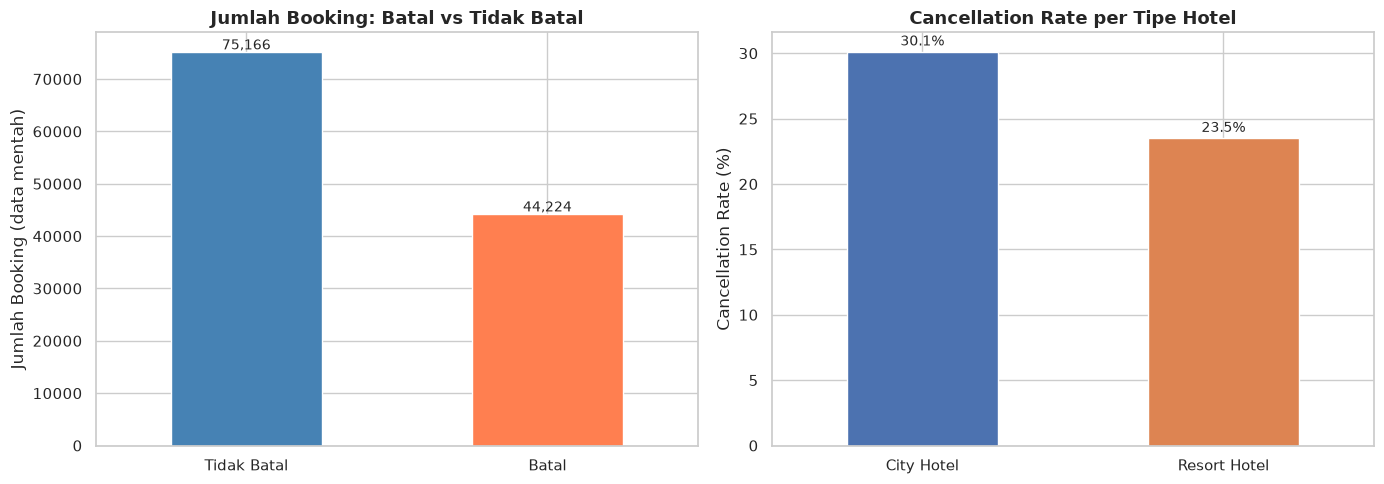

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target_dist.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('Jumlah Booking: Batal vs Tidak Batal', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Jumlah Booking (data mentah)')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(target_dist):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

hotel_rate = df_fe.groupby('hotel')['is_canceled'].mean() * 100
hotel_rate.plot(kind='bar', ax=axes[1], color=['#4c72b0', '#dd8452'], edgecolor='white')
axes[1].set_title('Cancellation Rate per Tipe Hotel', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(hotel_rate):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

City Hotel memiliki cancellation rate yang lebih tinggi dibanding Resort Hotel. Tamu City Hotel cenderung
lebih fleksibel (perjalanan bisnis/singkat), sedangkan tamu Resort Hotel umumnya merencanakan liburan lebih matang.

**Lead Time vs Pembatalan**

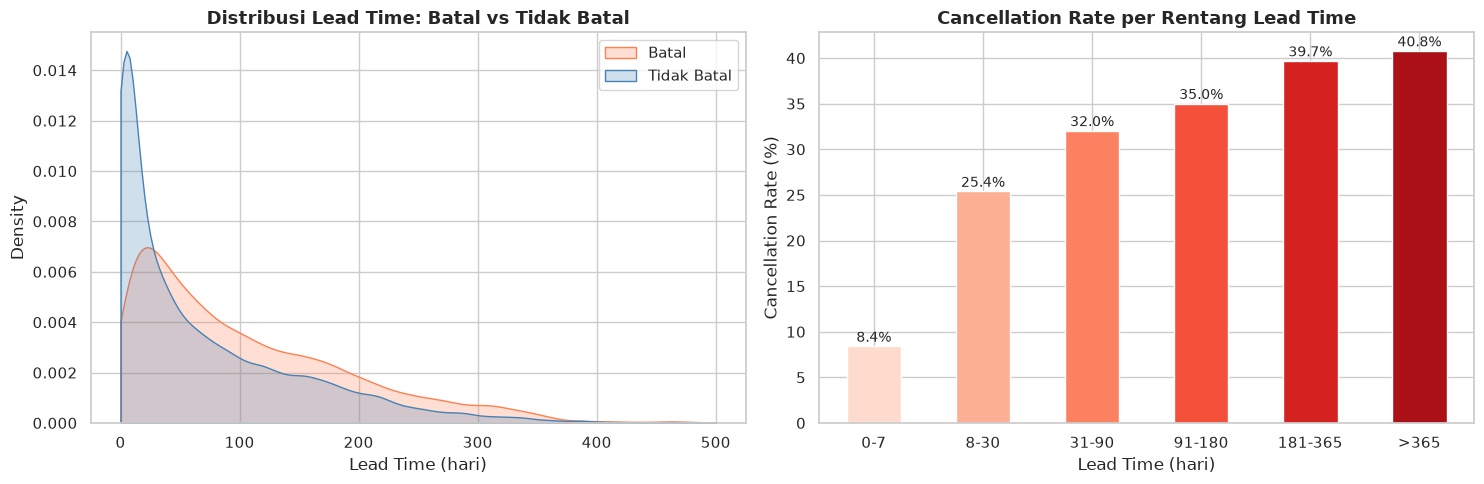

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.kdeplot(data=df_fe, x='lead_time', hue='is_canceled', common_norm=False, fill=True,
            palette={0: 'steelblue', 1: 'coral'}, ax=axes[0], clip=(0, 500))
axes[0].set_title('Distribusi Lead Time: Batal vs Tidak Batal', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Lead Time (hari)')
axes[0].legend(['Batal', 'Tidak Batal'])

bins   = [-1, 7, 30, 90, 180, 365, 800]
labels = ['0-7', '8-30', '31-90', '91-180', '181-365', '>365']
lead_bin  = pd.cut(df_fe['lead_time'], bins=bins, labels=labels)
lead_rate = df_fe.groupby(lead_bin, observed=True)['is_canceled'].mean() * 100
lead_rate.plot(kind='bar', ax=axes[1], color=sns.color_palette('Reds', len(lead_rate)), edgecolor='white')
axes[1].set_title('Cancellation Rate per Rentang Lead Time', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Lead Time (hari)')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(lead_rate):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Semakin jauh jarak antara tanggal booking dan tanggal kedatangan, semakin tinggi peluang pembatalan.
Booking yang dibuat jauh hari memberi tamu lebih banyak waktu untuk berubah rencana.

**Deposit Type, Customer Type, dan Market Segment**

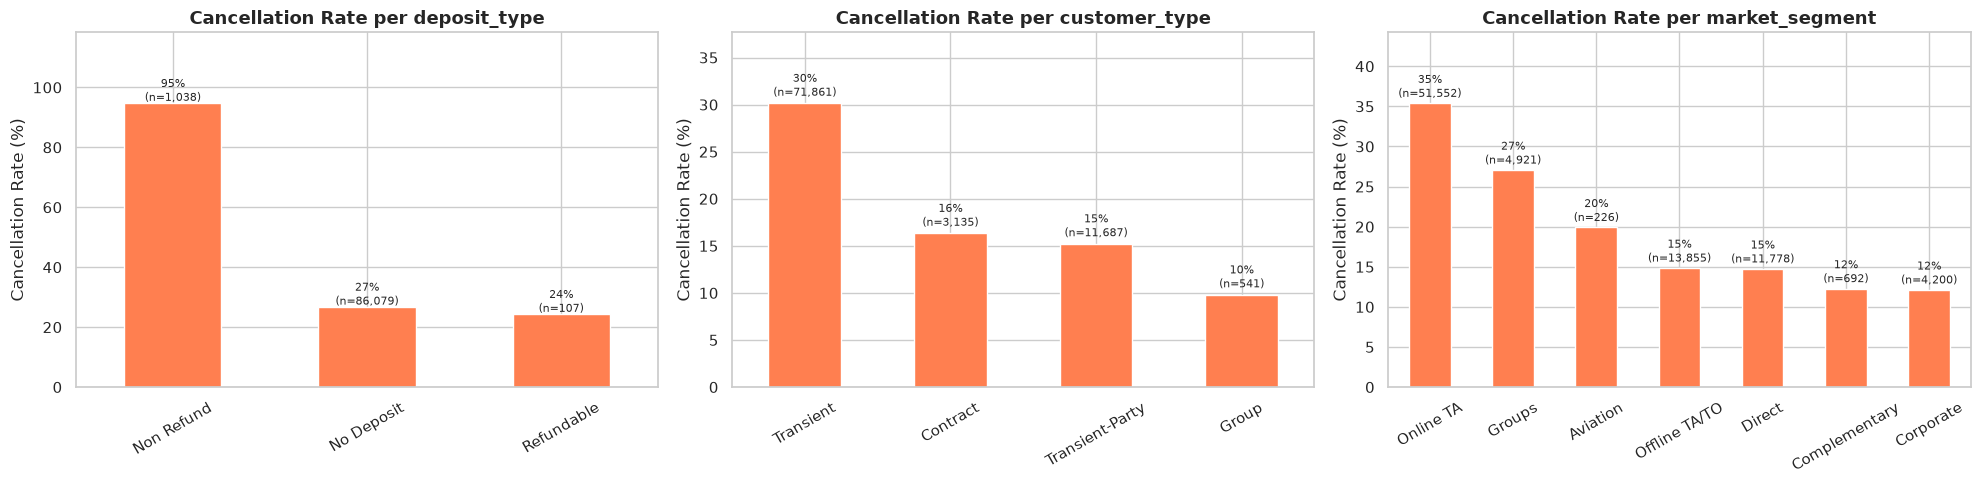

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, col in zip(axes, ['deposit_type', 'customer_type', 'market_segment']):
    rate  = df_fe.groupby(col)['is_canceled'].mean().sort_values(ascending=False) * 100
    count = df_fe[col].value_counts()
    rate.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
    ax.set_title(f'Cancellation Rate per {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Cancellation Rate (%)')
    ax.tick_params(axis='x', rotation=30)
    for i, (k, v) in enumerate(rate.items()):
        ax.text(i, v + 0.8, f'{v:.0f}%\n(n={count[k]:,})', ha='center', fontsize=8)
    ax.set_ylim(0, rate.max() * 1.25)

plt.tight_layout()
plt.show()

- **Non Refund** memiliki cancellation rate yang sangat tinggi, berlawanan dengan intuisi. Pola ini sudah dikenal
  pada dataset ini: booking Non Refund banyak berasal dari grup/agen (terutama di City Hotel) yang membatalkan
  dalam jumlah besar. Model tetap bisa memanfaatkan pola ini, tetapi interpretasinya perlu hati-hati.
- Segmen **Groups** dan **Online TA** memiliki cancellation rate tertinggi, sedangkan **Direct** dan
  **Corporate** relatif rendah.

**Tren Bulanan: Volume Booking dan Cancellation Rate**

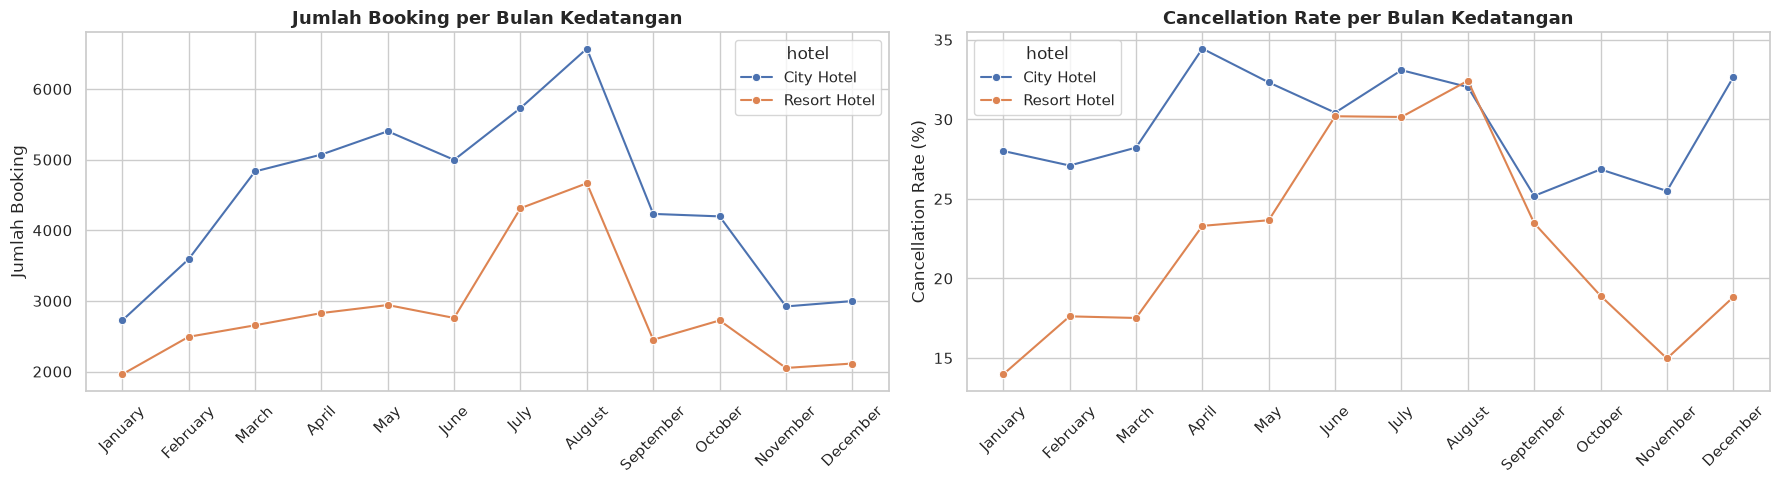

In [22]:
monthly = df_fe.groupby(['arrival_date_month', 'hotel']).agg(
    bookings=('is_canceled', 'size'),
    cancel_rate=('is_canceled', 'mean')
).reset_index()
monthly['arrival_date_month'] = pd.Categorical(monthly['arrival_date_month'], categories=month_order, ordered=True)
monthly = monthly.sort_values('arrival_date_month')
monthly['cancel_rate'] *= 100

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.lineplot(data=monthly, x='arrival_date_month', y='bookings', hue='hotel', marker='o', ax=axes[0])
axes[0].set_title('Jumlah Booking per Bulan Kedatangan', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Jumlah Booking')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=monthly, x='arrival_date_month', y='cancel_rate', hue='hotel', marker='o', ax=axes[1])
axes[1].set_title('Cancellation Rate per Bulan Kedatangan', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Volume booking memuncak pada musim panas (Juli - Agustus). Cancellation rate juga cenderung lebih tinggi
pada bulan-bulan ramai, terutama untuk City Hotel.

**Special Request, Parkir, dan Tamu Berulang**

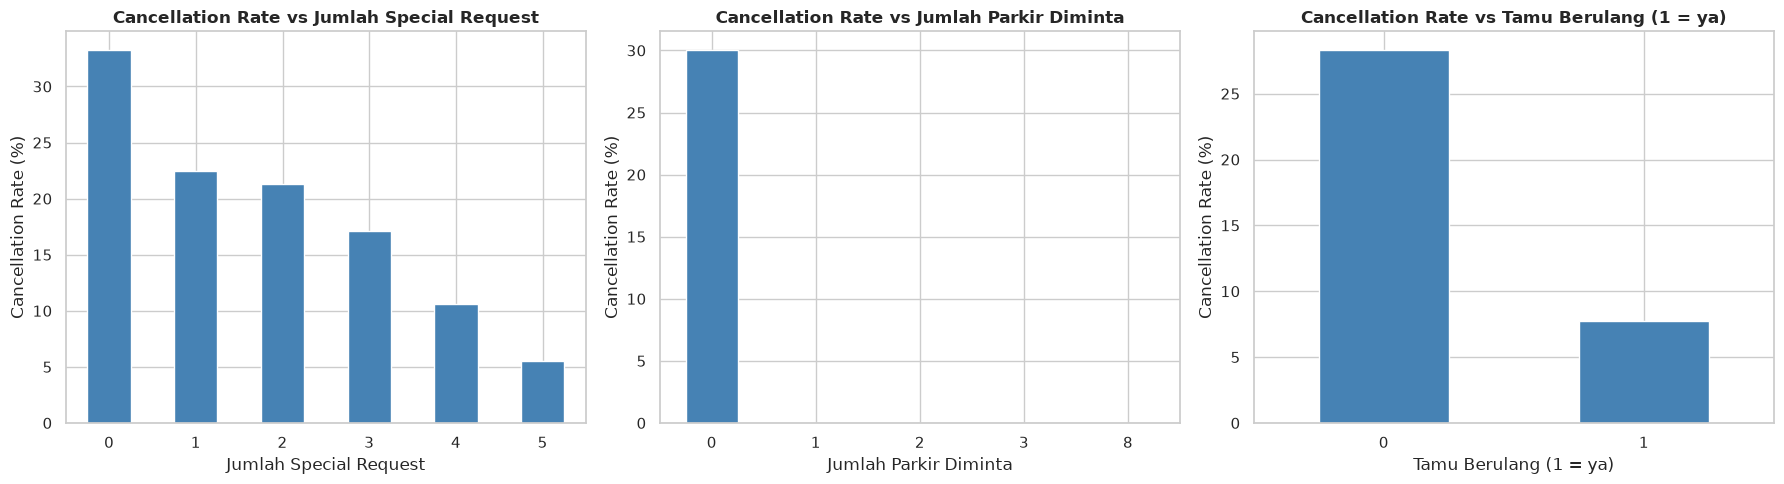

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(
    axes,
    ['total_of_special_requests', 'required_car_parking_spaces', 'is_repeated_guest'],
    ['Jumlah Special Request', 'Jumlah Parkir Diminta', 'Tamu Berulang (1 = ya)']
):
    rate = df_fe.groupby(col)['is_canceled'].mean() * 100
    rate.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Cancellation Rate vs {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Cancellation Rate (%)')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

- Tamu yang mengajukan **special request** jauh lebih jarang membatalkan; request menunjukkan komitmen.
- Tamu yang meminta **parkir** hampir tidak pernah membatalkan dalam data ini.
- **Tamu berulang** (repeated guest) lebih loyal dan cancellation rate-nya lebih rendah.

**Top 10 Negara Asal Tamu**

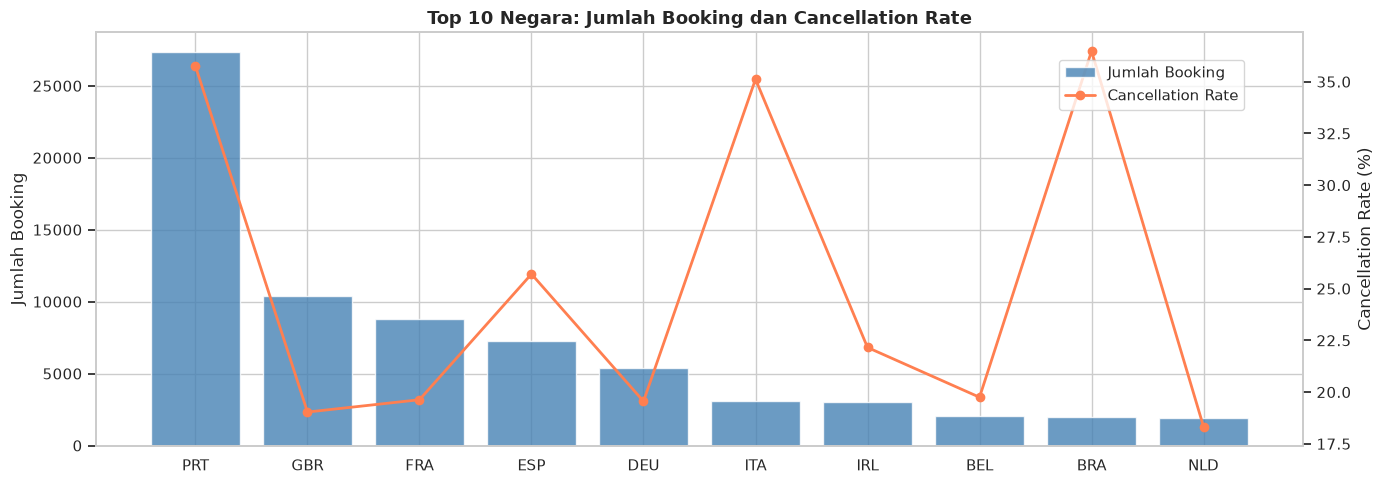

In [24]:
top_country = df_fe['country'].value_counts().nlargest(10).index
country_stats = (df_fe[df_fe['country'].isin(top_country)]
                 .groupby('country')['is_canceled'].agg(['size', 'mean'])
                 .sort_values('size', ascending=False))

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(country_stats.index, country_stats['size'], color='steelblue', alpha=0.8, label='Jumlah Booking')
ax1.set_ylabel('Jumlah Booking')
ax2 = ax1.twinx()
ax2.plot(country_stats.index, country_stats['mean'] * 100, color='coral', marker='o', linewidth=2,
         label='Cancellation Rate')
ax2.set_ylabel('Cancellation Rate (%)')
ax2.grid(False)
ax1.set_title('Top 10 Negara: Jumlah Booking dan Cancellation Rate', fontsize=13, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.show()

Portugal (PRT) sebagai negara lokasi hotel mendominasi jumlah booking dan juga memiliki cancellation rate
tertinggi dibanding negara lain. Hal ini melatarbelakangi fitur `is_local`.

**ADR (Average Daily Rate) vs Pembatalan**

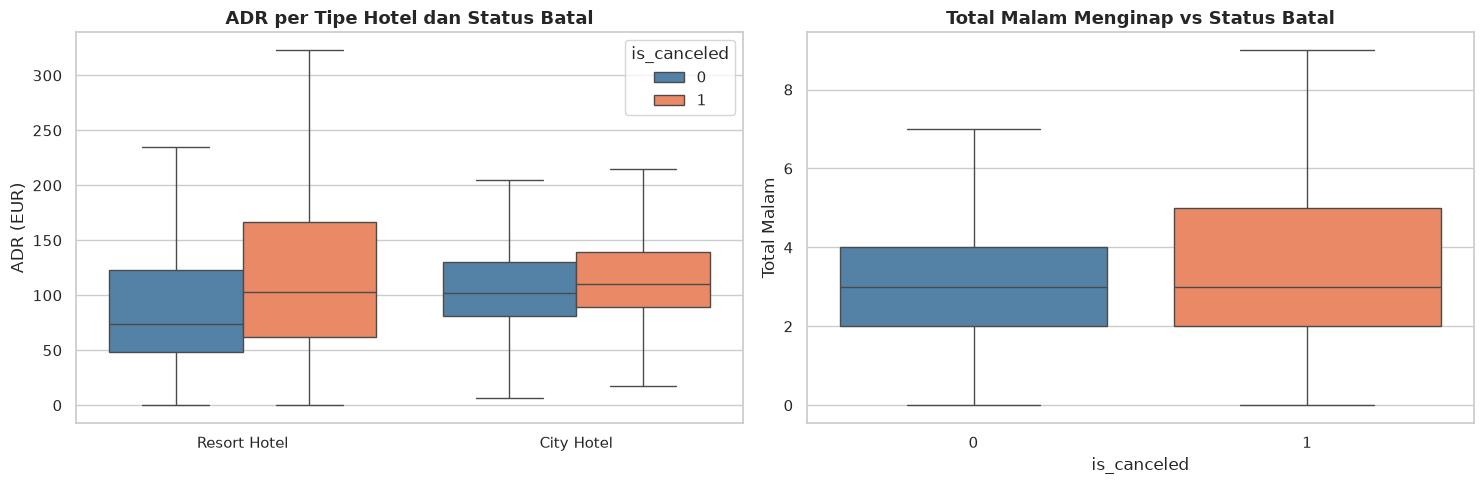

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df_fe, x='hotel', y='adr', hue='is_canceled', showfliers=False,
            palette={0: 'steelblue', 1: 'coral'}, ax=axes[0])
axes[0].set_title('ADR per Tipe Hotel dan Status Batal', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('ADR (EUR)')
axes[0].legend(title='is_canceled')

sns.boxplot(data=df_fe, x='is_canceled', y='total_nights', showfliers=False,
            palette=['steelblue', 'coral'], ax=axes[1])
axes[1].set_title('Total Malam Menginap vs Status Batal', fontsize=13, fontweight='bold')
axes[1].set_xlabel('is_canceled')
axes[1].set_ylabel('Total Malam')

plt.tight_layout()
plt.show()

**Korelasi Fitur Numerik dengan Target**

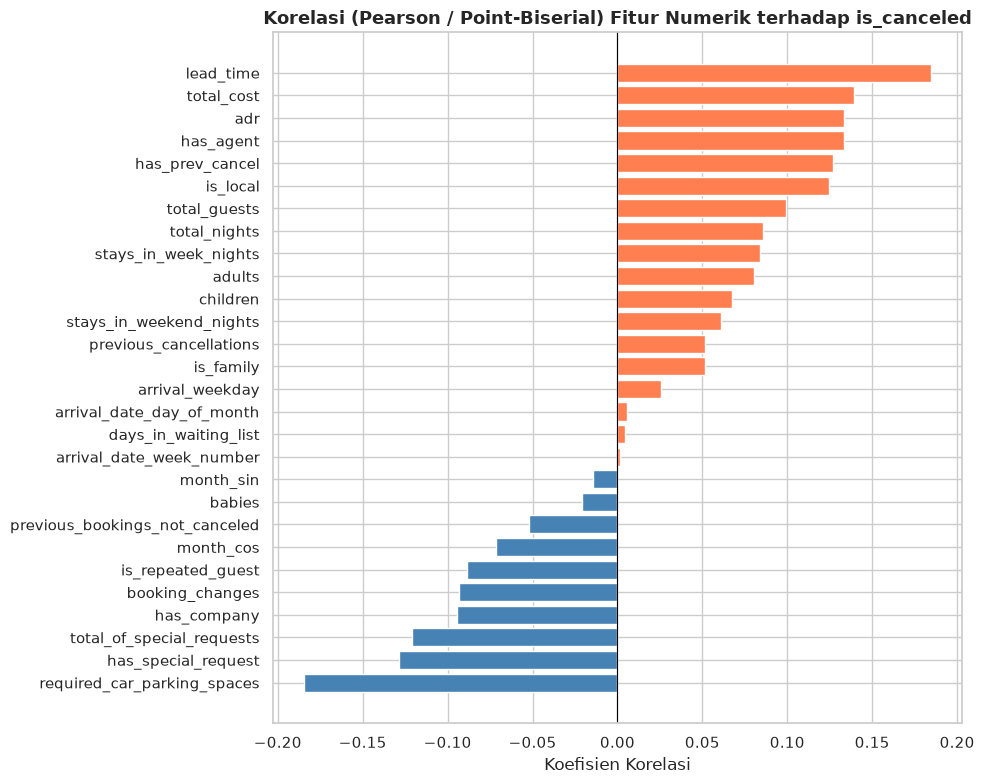

In [26]:
corr_cols = [c for c in num_cols if df_fe[c].nunique() > 1] + ['is_canceled']
corr_target = df_fe[corr_cols].corr()['is_canceled'].drop('is_canceled').sort_values()

plt.figure(figsize=(10, 8))
colors = ['coral' if v > 0 else 'steelblue' for v in corr_target]
plt.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Korelasi (Pearson / Point-Biserial) Fitur Numerik terhadap is_canceled',
          fontsize=13, fontweight='bold')
plt.xlabel('Koefisien Korelasi')
plt.tight_layout()
plt.show()

Grafik di atas menunjukkan arah dan kekuatan hubungan linear tiap fitur numerik dengan pembatalan:
batang merah menaikkan peluang batal (misalnya `lead_time` dan `is_local`), batang biru menurunkan
(misalnya special request, parkir, dan `booking_changes`). Korelasi linear ini hanya gambaran awal; hubungan non-linear akan ditangkap oleh model tree.

# **6. Hypothesis Testing**

> - Normality check (Shapiro-Wilk + Q-Q Plot) untuk menentukan uji parametrik atau non-parametrik.
> - Mann-Whitney U test: perbedaan `lead_time` dan `adr` antara booking batal vs tidak batal.
> - Chi-Square test + Cramer's V: asosiasi fitur kategorikal dengan pembatalan.
> - Logistic Regression (statsmodels Logit): signifikansi tiap fitur terhadap pembatalan.

Tingkat signifikansi yang digunakan: **alpha = 0.05**.

## 1. Normality Check

Uji apakah `lead_time` pada kedua kelompok (batal vs tidak batal) berdistribusi normal.
Shapiro-Wilk dijalankan pada subsample maksimal 5.000 baris karena tidak efisien untuk n besar.

In [27]:
group_cancel     = df_fe[df_fe['is_canceled'] == 1]
group_not_cancel = df_fe[df_fe['is_canceled'] == 0]

rng = np.random.default_rng(RANDOM_STATE)
n_sample = min(5000, len(group_cancel), len(group_not_cancel))
s_cancel     = rng.choice(group_cancel['lead_time'].values, size=n_sample, replace=False)
s_not_cancel = rng.choice(group_not_cancel['lead_time'].values, size=n_sample, replace=False)

stat_c, p_norm_c = stats.shapiro(s_cancel)
stat_n, p_norm_n = stats.shapiro(s_not_cancel)

print("Shapiro-Wilk Test (lead_time)")
print(f"  Batal       : W = {stat_c:.4f}, p-value = {p_norm_c:.2e} -> {'Normal' if p_norm_c > 0.05 else 'Tidak Normal'}")
print(f"  Tidak Batal : W = {stat_n:.4f}, p-value = {p_norm_n:.2e} -> {'Normal' if p_norm_n > 0.05 else 'Tidak Normal'}")

Shapiro-Wilk Test (lead_time)
  Batal       : W = 0.9012, p-value = 5.17e-49 -> Tidak Normal
  Tidak Batal : W = 0.8113, p-value = 1.70e-60 -> Tidak Normal


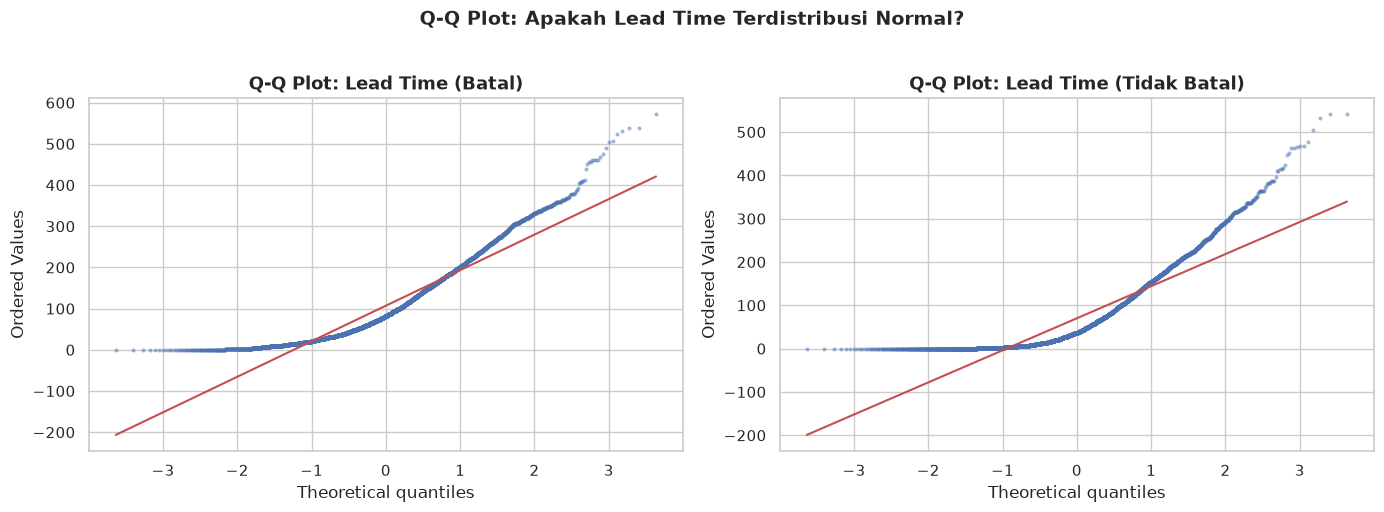

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stats.probplot(s_cancel, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q Plot: Lead Time (Batal)', fontsize=13, fontweight='bold')
axes[0].get_lines()[0].set(markersize=2, alpha=0.4)

stats.probplot(s_not_cancel, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: Lead Time (Tidak Batal)', fontsize=13, fontweight='bold')
axes[1].get_lines()[0].set(markersize=2, alpha=0.4)

plt.suptitle('Q-Q Plot: Apakah Lead Time Terdistribusi Normal?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Kedua kelompok **tidak berdistribusi normal** (right-skewed, titik melengkung menjauhi garis diagonal).
Oleh karena itu, perbandingan dua kelompok menggunakan uji **non-parametrik Mann-Whitney U**.

## 2. Mann-Whitney U Test: Lead Time dan ADR

**Hipotesis (untuk tiap variabel):**
- H0: Distribusi variabel sama antara booking batal dan tidak batal
- H1: Distribusi variabel berbeda antara booking batal dan tidak batal

Effect size diukur dengan **rank-biserial correlation** (r): |r| < 0.1 sangat kecil, 0.1 - 0.3 kecil,
0.3 - 0.5 sedang, > 0.5 besar.

In [29]:
results_mw = []
for col in ['lead_time', 'adr', 'total_nights', 'total_of_special_requests']:
    a = group_cancel[col]
    b = group_not_cancel[col]
    u_stat, p_mw = stats.mannwhitneyu(a, b, alternative='two-sided')
    r_rb = 1 - 2 * u_stat / (len(a) * len(b))
    results_mw.append({
        'Variabel'            : col,
        'Median Batal'        : a.median(),
        'Median Tidak Batal'  : b.median(),
        'U-Statistic'         : u_stat,
        'P-Value'             : p_mw,
        'Rank-Biserial r'     : round(-r_rb, 4),
        'Kesimpulan'          : 'H0 ditolak (berbeda)' if p_mw < 0.05 else 'Gagal tolak H0',
    })

mw_df = pd.DataFrame(results_mw)
mw_df

,Variabel,Median Batal,Median Tidak Batal,U-Statistic,P-Value,Rank-Biserial r,Kesimpulan
0,lead_time,80.0,38.00,980681342.0,0.000000e+00,0.2924,H0 ditolak (berbeda)
1,adr,109.8,94.89,898308807.5,0.000000e+00,0.1839,H0 ditolak (berbeda)
2,total_nights,3.0,3.00,859737440.0,1.732071e-208,0.1330,H0 ditolak (berbeda)
3,total_of_special_requests,0.0,1.00,644166097.5,0.000000e+00,-0.1511,H0 ditolak (berbeda)


Keempat variabel berbeda signifikan antara booking batal dan tidak batal. Berdasarkan effect size,
`lead_time` memiliki perbedaan paling besar (median booking batal sekitar dua kali lipat), disusul `adr`
(booking batal cenderung berharga lebih mahal) dan `total_of_special_requests` (booking batal lebih sedikit
request, r bernilai negatif). Semua effect size tergolong kecil sampai mendekati sedang; dengan n sebesar ini,
perbedaan kecil pun mudah signifikan sehingga effect size penting untuk dibaca.

## 3. Chi-Square Test: Asosiasi Fitur Kategorikal dengan Pembatalan

**Hipotesis (untuk tiap fitur):**
- H0: Tidak ada asosiasi antara fitur dan status pembatalan (independen)
- H1: Ada asosiasi signifikan antara fitur dan status pembatalan

**Cramer's V** digunakan untuk mengukur kekuatan asosiasi: < 0.1 lemah, 0.1 - 0.3 sedang, > 0.3 kuat.

In [30]:
def cramers_v(contingency, chi2):
    n = contingency.values.sum()
    return np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

chi_cols = ['hotel', 'deposit_type', 'market_segment', 'distribution_channel', 'customer_type',
            'meal', 'reserved_room_type', 'is_repeated_guest', 'has_special_request', 'is_local', 'is_family']

results_chi = []
for col in chi_cols:
    ct = pd.crosstab(df_fe[col], df_fe['is_canceled'])
    chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
    results_chi.append({
        'Fitur'      : col,
        'Chi2'       : round(chi2, 2),
        'dof'        : dof,
        'P-Value'    : p_chi,
        "Cramer's V" : round(cramers_v(ct, chi2), 4),
        'Kesimpulan' : 'H0 ditolak (ada asosiasi)' if p_chi < 0.05 else 'Gagal tolak H0',
    })

chi_df = pd.DataFrame(results_chi).sort_values("Cramer's V", ascending=False).reset_index(drop=True)
chi_df

,Fitur,Chi2,dof,P-Value,Cramer's V,Kesimpulan
0,market_segment,4265.30,6,0.000000e+00,0.2211,H0 ditolak (ada asosiasi)
1,deposit_type,2377.17,2,0.000000e+00,0.1651,H0 ditolak (ada asosiasi)
2,distribution_channel,2020.65,3,0.000000e+00,0.1522,H0 ditolak (ada asosiasi)
3,has_special_request,1447.94,1,0.000000e+00,0.1288,H0 ditolak (ada asosiasi)
4,customer_type,1415.90,3,1.046408e-306,0.1274,H0 ditolak (ada asosiasi)
5,is_local,1352.43,1,4.575643e-296,0.1245,H0 ditolak (ada asosiasi)
6,is_repeated_guest,685.74,1,3.771344e-151,0.0887,H0 ditolak (ada asosiasi)
7,hotel,453.77,1,1.091524e-100,0.0721,H0 ditolak (ada asosiasi)
8,meal,279.60,3,2.580198e-60,0.0566,H0 ditolak (ada asosiasi)
9,reserved_room_type,277.95,8,2.013803e-55,0.0565,H0 ditolak (ada asosiasi)


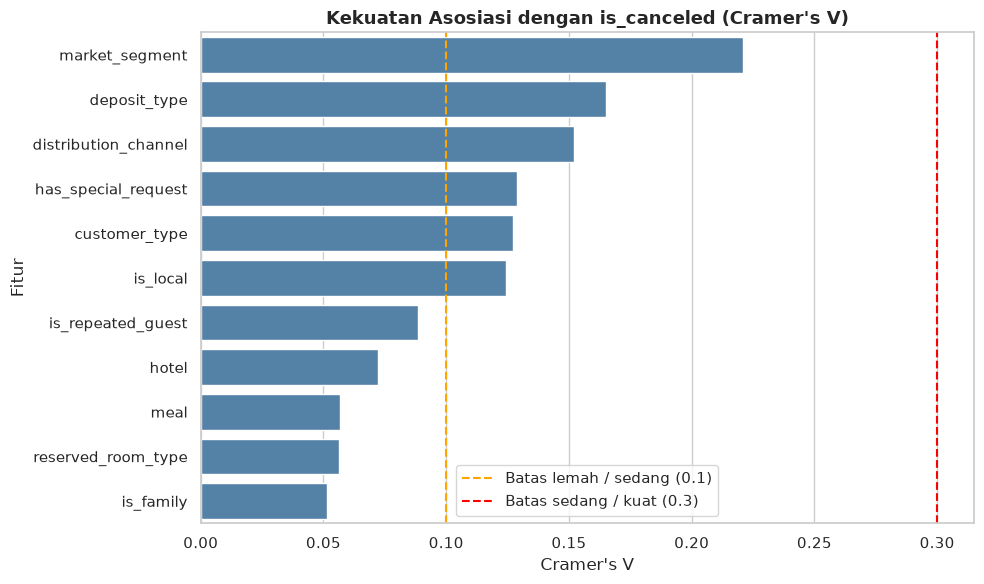

In [31]:
plt.figure(figsize=(10, 6))
sns.barplot(data=chi_df, y='Fitur', x="Cramer's V", color='steelblue')
plt.axvline(0.1, color='orange', linestyle='--', label='Batas lemah / sedang (0.1)')
plt.axvline(0.3, color='red', linestyle='--', label='Batas sedang / kuat (0.3)')
plt.title("Kekuatan Asosiasi dengan is_canceled (Cramer's V)", fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

Semua fitur kategorikal yang diuji memiliki asosiasi signifikan dengan pembatalan. Asosiasi terkuat (Cramer's V
kategori sedang) ada pada `market_segment`, `deposit_type`, `distribution_channel`, `has_special_request`,
`customer_type`, dan `is_local`, sejalan dengan temuan EDA. `hotel`, `meal`, `reserved_room_type`, dan `is_family`
signifikan tetapi asosiasinya lemah.

## 4. Logistic Regression-Based Hypothesis Testing (statsmodels Logit)

Analog dengan uji OLS pada regresi, di sini digunakan **Logit** untuk menguji apakah tiap fitur berpengaruh
signifikan terhadap log-odds pembatalan (H0: koefisien = 0). Fitur numerik distandarisasi agar koefisien
dapat dibandingkan. Untuk kestabilan estimasi, `country` direpresentasikan oleh `is_local` saja.

In [32]:
logit_num = ['lead_time', 'adr', 'total_nights', 'total_guests', 'booking_changes',
             'days_in_waiting_list', 'previous_cancellations', 'previous_bookings_not_canceled',
             'required_car_parking_spaces', 'total_of_special_requests', 'is_repeated_guest',
             'has_agent', 'has_company', 'is_local', 'is_family', 'month_sin', 'month_cos']
logit_cat = ['hotel', 'deposit_type', 'customer_type', 'distribution_channel']

df_logit = df_fe[logit_num + logit_cat + ['is_canceled']].copy()
df_logit[logit_num] = (df_logit[logit_num] - df_logit[logit_num].mean()) / df_logit[logit_num].std()
X_logit = pd.get_dummies(df_logit[logit_num + logit_cat], columns=logit_cat, drop_first=True, dtype=float)
X_logit = sm.add_constant(X_logit)

print("Baseline (kategori referensi) untuk Logit:")
for col in logit_cat:
    print(f"  {col:<22}: {sorted(df_fe[col].unique())[0]}")

logit_model = sm.Logit(df_logit['is_canceled'], X_logit).fit(disp=0, maxiter=200)
print()
print(logit_model.summary2().tables[0].to_string(header=False, index=False))

Baseline (kategori referensi) untuk Logit:
  hotel                 : City Hotel
  deposit_type          : No Deposit
  customer_type         : Contract
  distribution_channel  : Corporate



             Model:            Logit           Method:        MLE
Dependent Variable:      is_canceled Pseudo R-squared:      0.215
              Date: 2026-09-27 03:15              AIC: 80642.2898
  No. Observations:            87224              BIC: 80895.4482
          Df Model:               26   Log-Likelihood:    -40294.
      Df Residuals:            87197          LL-Null:    -51320.
         Converged:           0.0000      LLR p-value:     0.0000
    No. Iterations:         200.0000            Scale:     1.0000


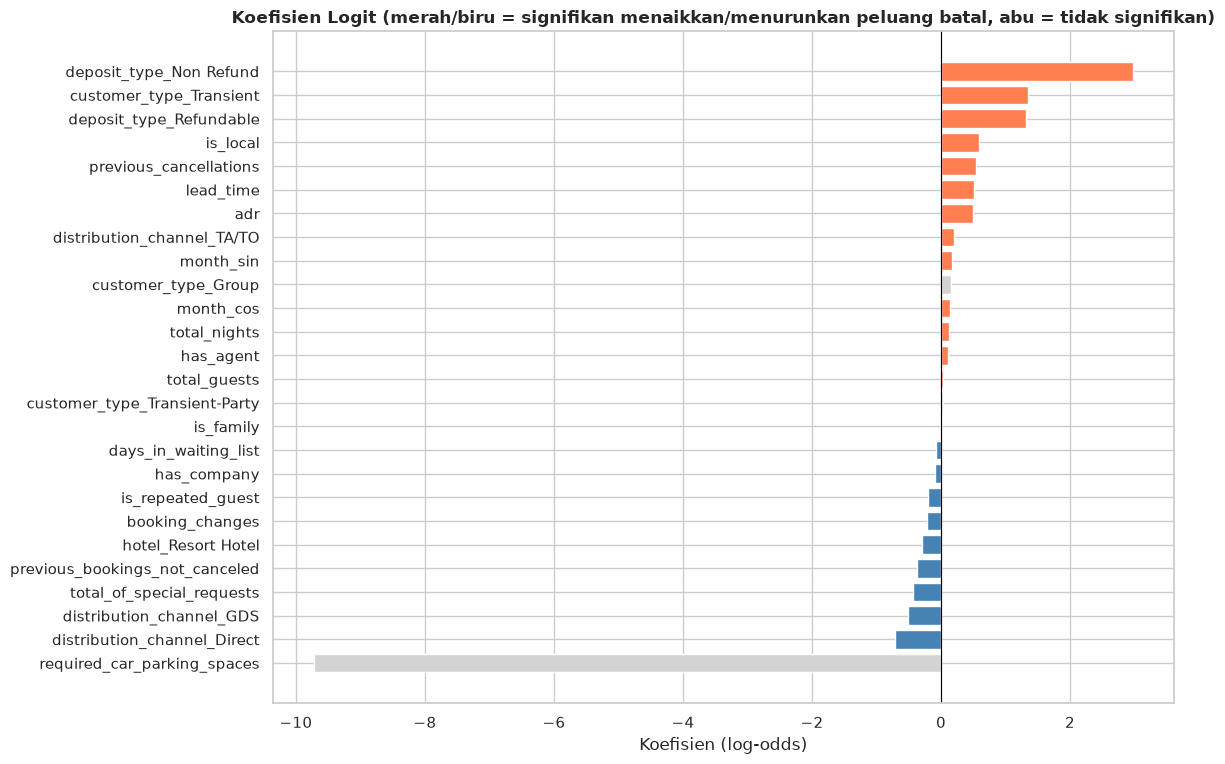

,Feature,Coef,Odds Ratio,P-Value,Significant
0,deposit_type_Non Refund,2.9764,19.6166,0.0000,True
1,customer_type_Transient,1.3452,3.8388,0.0000,True
2,deposit_type_Refundable,1.3220,3.7508,0.0000,True
3,is_local,0.5955,1.8139,0.0000,True
4,previous_cancellations,0.5448,1.7242,0.0000,True
5,lead_time,0.5177,1.6782,0.0000,True
6,adr,0.4953,1.6409,0.0000,True
7,distribution_channel_TA/TO,0.2053,1.2278,0.0110,True
8,month_sin,0.1688,1.1839,0.0000,True
9,customer_type_Group,0.1534,1.1658,0.3741,False


In [33]:
coef_df = pd.DataFrame({
    'Feature'   : logit_model.params.index,
    'Coef'      : logit_model.params.values,
    'Odds Ratio': np.exp(logit_model.params.values),
    'P-Value'   : logit_model.pvalues.values,
}).iloc[1:]
coef_df['Significant'] = coef_df['P-Value'] < 0.05
coef_df = coef_df.sort_values('Coef')

plt.figure(figsize=(12, max(6, len(coef_df) * 0.3)))
colors = ['coral' if (s and c > 0) else 'steelblue' if s else 'lightgray'
          for s, c in zip(coef_df['Significant'], coef_df['Coef'])]
plt.barh(coef_df['Feature'], coef_df['Coef'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Koefisien Logit (merah/biru = signifikan menaikkan/menurunkan peluang batal, abu = tidak signifikan)',
          fontsize=12, fontweight='bold')
plt.xlabel('Koefisien (log-odds)')
plt.tight_layout()
plt.show()

coef_df.sort_values('Coef', ascending=False).round(4).reset_index(drop=True)

Interpretasi odds ratio (OR): OR > 1 berarti fitur **menaikkan** peluang batal, OR < 1 berarti **menurunkan**.
Untuk fitur numerik, OR dihitung per kenaikan 1 standar deviasi.

## Ringkasan Hypothesis Testing

In [34]:
summary_tests = pd.DataFrame(
    [{'Uji': 'Shapiro-Wilk (Batal)', 'Tujuan': 'Normalitas lead_time', 'P-Value': f'{p_norm_c:.2e}',
      'Kesimpulan': 'Normal' if p_norm_c > 0.05 else 'Tidak Normal'},
     {'Uji': 'Shapiro-Wilk (Tidak Batal)', 'Tujuan': 'Normalitas lead_time', 'P-Value': f'{p_norm_n:.2e}',
      'Kesimpulan': 'Normal' if p_norm_n > 0.05 else 'Tidak Normal'}]
    + [{'Uji': 'Mann-Whitney U', 'Tujuan': f"{r['Variabel']} batal vs tidak batal",
        'P-Value': f"{r['P-Value']:.2e}", 'Kesimpulan': r['Kesimpulan']} for r in results_mw]
    + [{'Uji': 'Chi-Square', 'Tujuan': f"{r['Fitur']} vs is_canceled",
        'P-Value': f"{r['P-Value']:.2e}", 'Kesimpulan': r['Kesimpulan']} for _, r in chi_df.iterrows()]
    + [{'Uji': 'Logit Regression', 'Tujuan': 'Signifikansi fitur terhadap pembatalan',
        'P-Value': f"LLR p = {logit_model.llr_pvalue:.2e}",
        'Kesimpulan': f"{coef_df['Significant'].sum()} dari {len(coef_df)} fitur signifikan"}]
)
summary_tests

,Uji,Tujuan,P-Value,Kesimpulan
0,Shapiro-Wilk (Batal),Normalitas lead_time,5.17e-49,Tidak Normal
1,Shapiro-Wilk (Tidak Batal),Normalitas lead_time,1.70e-60,Tidak Normal
2,Mann-Whitney U,lead_time batal vs tidak batal,0.00e+00,H0 ditolak (berbeda)
3,Mann-Whitney U,adr batal vs tidak batal,0.00e+00,H0 ditolak (berbeda)
4,Mann-Whitney U,total_nights batal vs tidak batal,1.73e-208,H0 ditolak (berbeda)
5,Mann-Whitney U,total_of_special_requests batal vs tidak batal,0.00e+00,H0 ditolak (berbeda)
6,Chi-Square,market_segment vs is_canceled,0.00e+00,H0 ditolak (ada asosiasi)
7,Chi-Square,deposit_type vs is_canceled,0.00e+00,H0 ditolak (ada asosiasi)
8,Chi-Square,distribution_channel vs is_canceled,0.00e+00,H0 ditolak (ada asosiasi)
9,Chi-Square,has_special_request vs is_canceled,0.00e+00,H0 ditolak (ada asosiasi)


# **7. Modeling: Baseline Models**

Tiga model dibandingkan dengan pengaturan default (baseline):

| Model | Karakteristik |
|---|---|
| **Logistic Regression** | Model linear, mudah diinterpretasi, jadi pembanding sederhana |
| **Random Forest** | Ensemble bagging dari decision tree, menangkap non-linearitas dan interaksi |
| **XGBoost** | Ensemble gradient boosting, biasanya unggul pada data tabular |

Setiap model dibungkus dalam `Pipeline` bersama preprocessor, sehingga encoding dan scaling di-*fit* ulang
di setiap fold cross-validation (tidak ada leakage antar fold).

In [35]:
def make_pipeline(model):
    return Pipeline([('prep', make_preprocessor()), ('model', model)])

baseline_models = {
    'Logistic Regression': make_pipeline(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    'Random Forest'      : make_pipeline(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)),
    'XGBoost'            : make_pipeline(XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)),
}

**Train (Fitting) dan Evaluasi Baseline pada Data Test**

In [36]:
def evaluate(model, x, y_true):
    y_pred  = model.predict(x)
    y_proba = model.predict_proba(x)[:, 1]
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall'   : recall_score(y_true, y_pred),
        'F1-Score' : f1_score(y_true, y_pred),
        'ROC-AUC'  : roc_auc_score(y_true, y_proba),
    }

baseline_results = {}
for name, pipe in baseline_models.items():
    start = time.time()
    pipe.fit(x_train, y_train)
    baseline_results[name] = evaluate(pipe, x_test, y_test)
    baseline_results[name]['Train Time (s)'] = round(time.time() - start, 2)

baseline_df = pd.DataFrame(baseline_results).T
baseline_df.round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s)
Logistic Regression,0.7958,0.6908,0.4672,0.5574,0.8379,2.25
Random Forest,0.8328,0.7469,0.5938,0.6616,0.8907,3.49
XGBoost,0.8299,0.7286,0.6088,0.6633,0.8934,0.95


Model berbasis tree (Random Forest dan XGBoost) jauh mengungguli Logistic Regression, menandakan
hubungan fitur dengan pembatalan bersifat **non-linear** dan melibatkan interaksi antar fitur.

**Cek Overfitting Baseline: Train vs Test**

In [37]:
overfit_rows = []
for name, pipe in baseline_models.items():
    tr = evaluate(pipe, x_train, y_train)
    te = baseline_results[name]
    overfit_rows.append({'Model': name,
                         'Train ROC-AUC': tr['ROC-AUC'], 'Test ROC-AUC': te['ROC-AUC'],
                         'Train F1': tr['F1-Score'], 'Test F1': te['F1-Score']})
pd.DataFrame(overfit_rows).set_index('Model').round(4)

,Train ROC-AUC,Test ROC-AUC,Train F1,Test F1
Model,,,,
Logistic Regression,0.8382,0.8379,0.5633,0.5574
Random Forest,1.0000,0.8907,0.9948,0.6616
XGBoost,0.9293,0.8934,0.7308,0.6633


Random Forest baseline (tanpa batasan kedalaman) hampir sempurna di data train namun turun di data test:
indikasi **overfitting**. Ini salah satu alasan hyperparameter tuning diperlukan.

**Top 15 Feature Importance: Baseline Random Forest vs XGBoost**

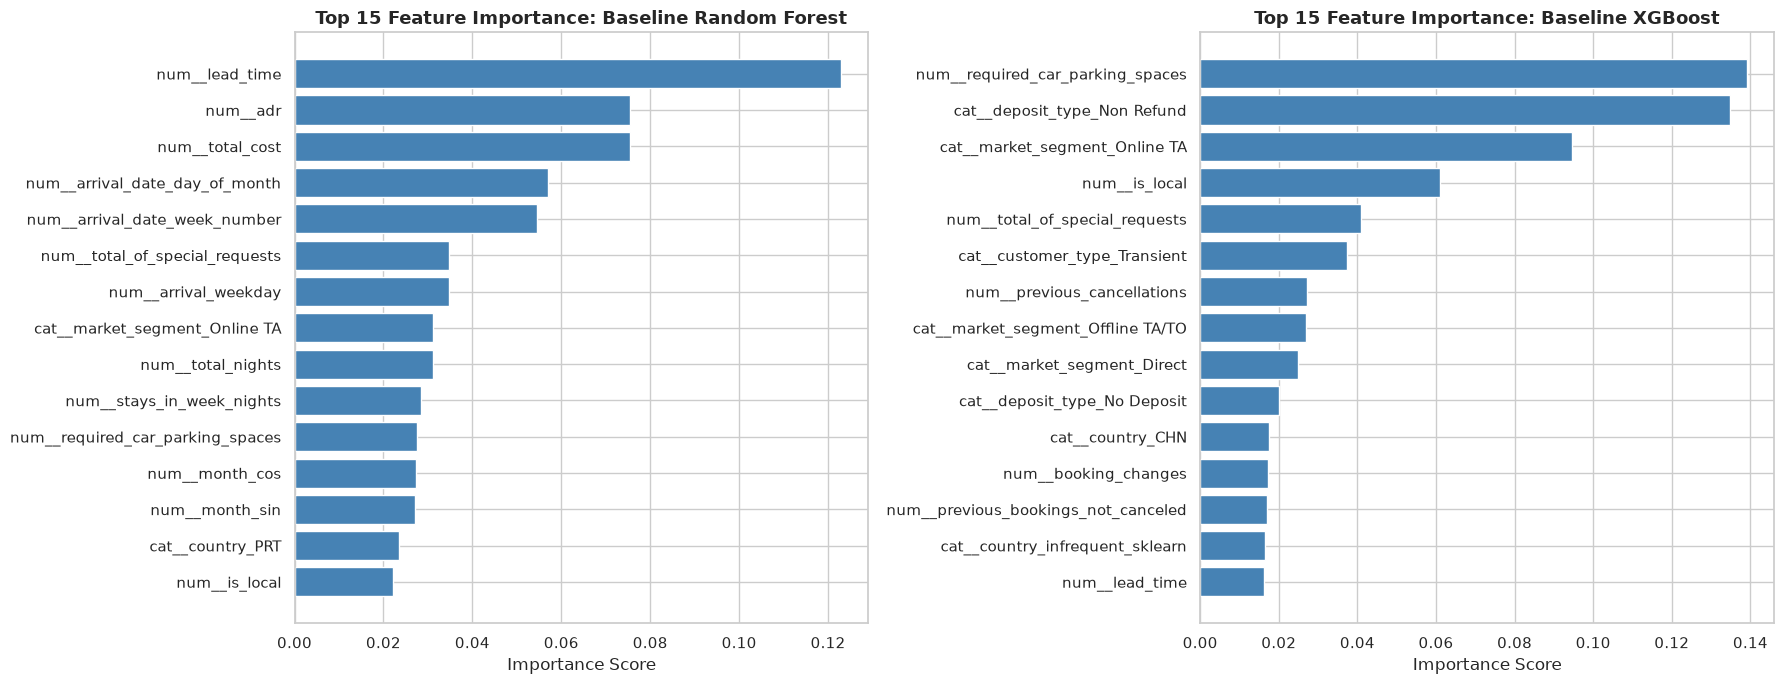

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, name in zip(axes, ['Random Forest', 'XGBoost']):
    imp = pd.Series(baseline_models[name].named_steps['model'].feature_importances_,
                    index=feature_names_out).nlargest(15).sort_values()
    ax.barh(imp.index, imp.values, color='steelblue', edgecolor='white')
    ax.set_title(f'Top 15 Feature Importance: Baseline {name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

# **8. Hyperparameter Tuning & Cross-Validation**

## Step 1: Stratified K-Fold Cross-Validation Setup

`StratifiedKFold` digunakan agar proporsi kelas batal/tidak batal sama di setiap fold.

In [39]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['roc_auc', 'f1', 'accuracy', 'precision', 'recall']

print("Stratified K-Fold Configuration:")
print(f"  Number of Folds : {skf.n_splits}")
print(f"  Shuffle         : True")
print(f"  Random State    : {RANDOM_STATE}")

cv_baseline = {}
for name, pipe in baseline_models.items():
    cv_baseline[name] = cross_validate(pipe, x_train, y_train, cv=skf, scoring=scoring, n_jobs=1)
    print(f"\n{name}")
    print(f"  ROC-AUC per fold : {np.round(cv_baseline[name]['test_roc_auc'], 4)}")
    print(f"  Mean ROC-AUC     : {cv_baseline[name]['test_roc_auc'].mean():.4f} "
          f"(+/- {cv_baseline[name]['test_roc_auc'].std():.4f})")

Stratified K-Fold Configuration:
  Number of Folds : 5
  Shuffle         : True
  Random State    : 42



Logistic Regression
  ROC-AUC per fold : [0.8383 0.8375 0.8377 0.8377 0.8339]
  Mean ROC-AUC     : 0.8370 (+/- 0.0016)



Random Forest
  ROC-AUC per fold : [0.8894 0.8933 0.892  0.8877 0.8865]
  Mean ROC-AUC     : 0.8898 (+/- 0.0025)



XGBoost
  ROC-AUC per fold : [0.8913 0.8957 0.8944 0.8895 0.8869]
  Mean ROC-AUC     : 0.8916 (+/- 0.0032)


## Step 2: Define Hyperparameter Search Space

Search space didefinisikan untuk masing-masing model. Pencarian dilakukan dengan **RandomizedSearchCV**
(3-fold stratified, dioptimasi terhadap ROC-AUC) karena ruang kombinasinya terlalu besar untuk grid search penuh.

In [40]:
param_spaces = {
    'Logistic Regression': {
        'model__C'           : [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30],
        'model__solver'      : ['lbfgs'],
        'model__class_weight': [None, 'balanced'],
    },
    'Random Forest': {
        'model__n_estimators'     : [200, 300, 500],
        'model__max_depth'        : [None, 20, 30, 40],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf' : [1, 2, 4],
        'model__max_features'     : ['sqrt', 0.3, 0.5],
        'model__class_weight'     : [None, 'balanced'],
    },
    'XGBoost': {
        'model__n_estimators'    : [300, 500, 800],
        'model__max_depth'       : [4, 6, 8, 10],
        'model__learning_rate'   : [0.03, 0.05, 0.1, 0.2],
        'model__subsample'       : [0.7, 0.85, 1.0],
        'model__colsample_bytree': [0.6, 0.8, 1.0],
        'model__min_child_weight': [1, 3, 5],
        'model__gamma'           : [0, 0.1, 0.5],
    },
}
n_iters = {'Logistic Regression': 16, 'Random Forest': 15, 'XGBoost': 25}

for name, space in param_spaces.items():
    total = int(np.prod([len(v) for v in space.values()]))
    print(f"{name:<20}: {total:>5,} kombinasi, diuji {min(n_iters[name], total)} kombinasi acak")

Logistic Regression :    16 kombinasi, diuji 16 kombinasi acak
Random Forest       :   648 kombinasi, diuji 15 kombinasi acak
XGBoost             : 3,888 kombinasi, diuji 25 kombinasi acak


## Step 3: RandomizedSearchCV untuk Tiap Model

In [41]:
cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
searches = {}

for name, space in param_spaces.items():
    print(f"Tuning {name} ...")
    start = time.time()
    search = RandomizedSearchCV(
        estimator=baseline_models[name],
        param_distributions=space,
        n_iter=n_iters[name],
        cv=cv_tune,
        scoring='roc_auc',
        random_state=RANDOM_STATE,
        n_jobs=-1 if name == 'Logistic Regression' else 2,
        refit=True,
    )
    search.fit(x_train, y_train)
    searches[name] = search
    print(f"  Selesai dalam {time.time() - start:.1f} detik")
    print(f"  Best CV ROC-AUC : {search.best_score_:.4f}")
    print(f"  Best Params     : { {k.replace('model__', ''): v for k, v in search.best_params_.items()} }\n")

Tuning Logistic Regression ...


  Selesai dalam 11.2 detik
  Best CV ROC-AUC : 0.8371
  Best Params     : {'solver': 'lbfgs', 'class_weight': None, 'C': 0.03}

Tuning Random Forest ...


  Selesai dalam 498.0 detik
  Best CV ROC-AUC : 0.8925
  Best Params     : {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.3, 'max_depth': 40, 'class_weight': 'balanced'}

Tuning XGBoost ...


  Selesai dalam 119.9 detik
  Best CV ROC-AUC : 0.8940
  Best Params     : {'subsample': 0.7, 'n_estimators': 800, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8}



## Step 4: Extract & Lock Best Models

In [42]:
tuned_models = {name: s.best_estimator_ for name, s in searches.items()}

for name, s in searches.items():
    print("=" * 60)
    print(f"  {name}: PARAMETER TERBAIK")
    print("-" * 60)
    for k, v in s.best_params_.items():
        print(f"  {k.replace('model__', ''):<22} {v}")
print("=" * 60)

  Logistic Regression: PARAMETER TERBAIK
------------------------------------------------------------
  solver                 lbfgs
  class_weight           None
  C                      0.03
  Random Forest: PARAMETER TERBAIK
------------------------------------------------------------
  n_estimators           500
  min_samples_split      2
  min_samples_leaf       2
  max_features           0.3
  max_depth              40
  class_weight           balanced
  XGBoost: PARAMETER TERBAIK
------------------------------------------------------------
  subsample              0.7
  n_estimators           800
  min_child_weight       5
  max_depth              8
  learning_rate          0.05
  gamma                  0
  colsample_bytree       0.8


## Step 5: Cross-Validation Score Comparison (Baseline vs Tuned)

Model tuned dievaluasi ulang dengan 5-fold Stratified CV yang sama seperti baseline agar perbandingannya adil.

In [43]:
cv_tuned = {}
for name, pipe in tuned_models.items():
    cv_tuned[name] = cross_validate(pipe, x_train, y_train, cv=skf, scoring=scoring, n_jobs=1)

rows = []
for name in baseline_models:
    for label, cvres in [('Baseline', cv_baseline[name]), ('Tuned', cv_tuned[name])]:
        rows.append({
            'Model'         : name,
            'Versi'         : label,
            'CV ROC-AUC'    : cvres['test_roc_auc'].mean(),
            'CV ROC-AUC Std': cvres['test_roc_auc'].std(),
            'CV F1'         : cvres['test_f1'].mean(),
            'CV Accuracy'   : cvres['test_accuracy'].mean(),
            'CV Precision'  : cvres['test_precision'].mean(),
            'CV Recall'     : cvres['test_recall'].mean(),
        })
cv_comparison = pd.DataFrame(rows).set_index(['Model', 'Versi'])
cv_comparison.round(4)

CV ROC-AUC  CV ROC-AUC Std   CV F1  CV Accuracy  \
Model               Versi                                                       
Logistic Regression Baseline      0.8370          0.0016  0.5620       0.7959   
                    Tuned         0.8372          0.0016  0.5590       0.7958   
Random Forest       Baseline      0.8898          0.0025  0.6666       0.8351   
                    Tuned         0.8952          0.0026  0.7055       0.8249   
XGBoost             Baseline      0.8916          0.0032  0.6669       0.8307   
                    Tuned         0.8966          0.0033  0.6812       0.8364   

                              CV Precision  CV Recall  
Model               Versi                              
Logistic Regression Baseline        0.6865     0.4758  
                    Tuned           0.6890     0.4703  
Random Forest       Baseline        0.7517     0.5988  
                    Tuned           0.6567     0.7621  
XGBoost             Baseline        0.7270     0.6160  
                    Tuned           0.7342     0.6354

## Step 6: Visualisasi CV ROC-AUC per Fold

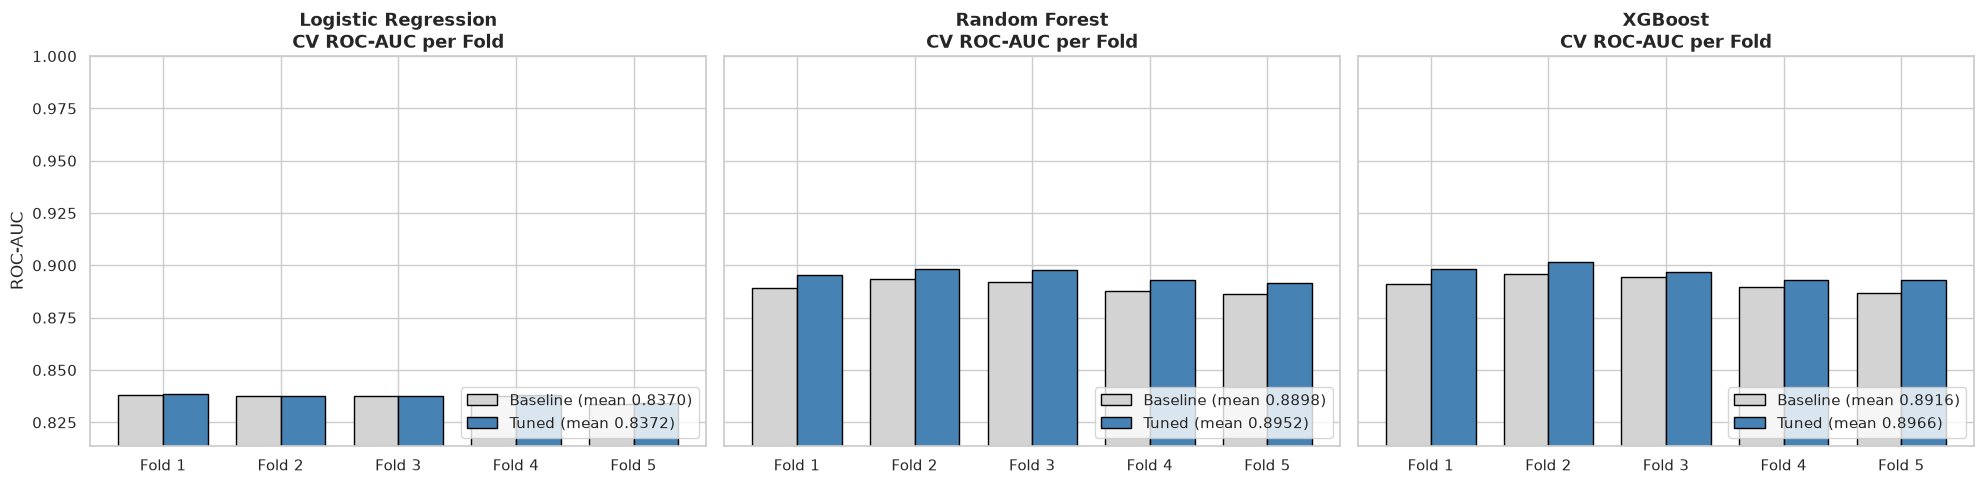

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
folds = [f'Fold {i + 1}' for i in range(skf.n_splits)]
width = 0.38
xpos = np.arange(len(folds))

for ax, name in zip(axes, baseline_models):
    b = cv_baseline[name]['test_roc_auc']
    t = cv_tuned[name]['test_roc_auc']
    ax.bar(xpos - width / 2, b, width, color='lightgray', edgecolor='black', label=f'Baseline (mean {b.mean():.4f})')
    ax.bar(xpos + width / 2, t, width, color='steelblue', edgecolor='black', label=f'Tuned (mean {t.mean():.4f})')
    ax.set_xticks(xpos)
    ax.set_xticklabels(folds)
    ax.set_title(f'{name}\nCV ROC-AUC per Fold', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right')

lo = min(min(cv_baseline[n]['test_roc_auc'].min(), cv_tuned[n]['test_roc_auc'].min()) for n in baseline_models)
axes[0].set_ylim(lo - 0.02, 1.0)
axes[0].set_ylabel('ROC-AUC')
plt.tight_layout()
plt.show()

## Step 7: Ringkasan Parameter Baseline vs Tuned

In [45]:
baseline_params_ref = {
    'Logistic Regression': {'C': 1.0, 'solver': 'lbfgs', 'class_weight': None},
    'Random Forest'      : {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2,
                            'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': None},
    'XGBoost'            : {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.3, 'subsample': 1.0,
                            'colsample_bytree': 1.0, 'min_child_weight': 1, 'gamma': 0},
}
param_rows = []
for name, params in baseline_params_ref.items():
    best = {k.replace('model__', ''): v for k, v in searches[name].best_params_.items()}
    for p, base_val in params.items():
        param_rows.append({'Model': name, 'Parameter': p,
                           'Baseline': str(base_val), 'Tuned': str(best.get(p, base_val))})
pd.DataFrame(param_rows).set_index(['Model', 'Parameter'])

Baseline     Tuned
Model               Parameter                           
Logistic Regression C                      1.0      0.03
                    solver               lbfgs     lbfgs
                    class_weight          None      None
Random Forest       n_estimators           100       500
                    max_depth             None        40
                    min_samples_split        2         2
                    min_samples_leaf         1         2
                    max_features          sqrt       0.3
                    class_weight          None  balanced
XGBoost             n_estimators           100       800
                    max_depth                6         8
                    learning_rate          0.3      0.05
                    subsample              1.0       0.7
                    colsample_bytree       1.0       0.8
                    min_child_weight         1         5
                    gamma                    0         0

# **9. Evaluation**

Seluruh model (baseline dan tuned) dievaluasi pada **data test** yang belum pernah dilihat selama training
maupun tuning.

In [46]:
tuned_results = {name: evaluate(pipe, x_test, y_test) for name, pipe in tuned_models.items()}

eval_rows = []
for name in baseline_models:
    eval_rows.append({'Model': name, 'Versi': 'Baseline', **{k: v for k, v in baseline_results[name].items() if k != 'Train Time (s)'}})
    eval_rows.append({'Model': name, 'Versi': 'Tuned', **tuned_results[name]})
test_comparison = pd.DataFrame(eval_rows).set_index(['Model', 'Versi'])
test_comparison.round(4).style.highlight_max(axis=0, color='lightgreen').format('{:.4f}')

**Perbandingan Metrik Model Tuned pada Data Test**

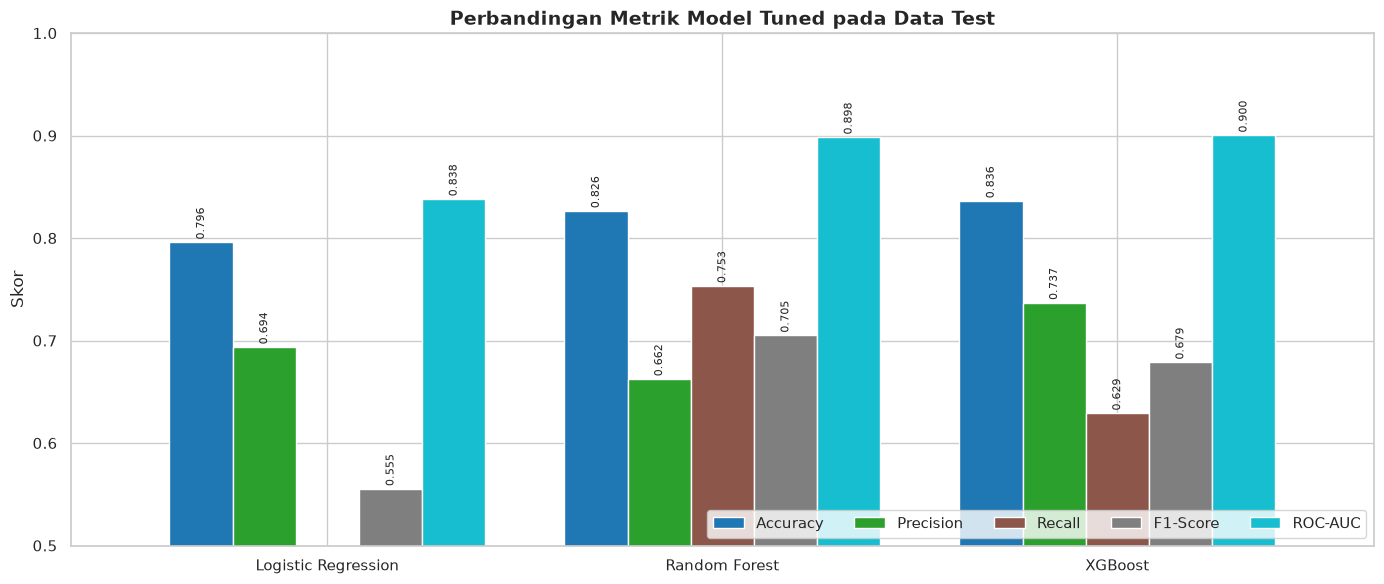

In [47]:
tuned_df = pd.DataFrame(tuned_results).T
ax = tuned_df.plot(kind='bar', figsize=(14, 6), colormap='tab10', edgecolor='white', width=0.8)
ax.set_title('Perbandingan Metrik Model Tuned pada Data Test', fontsize=14, fontweight='bold')
ax.set_ylabel('Skor')
ax.set_ylim(0.5, 1.0)
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='lower right', ncol=5)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, rotation=90, padding=2)
plt.tight_layout()
plt.show()

**ROC Curve dan Precision-Recall Curve**

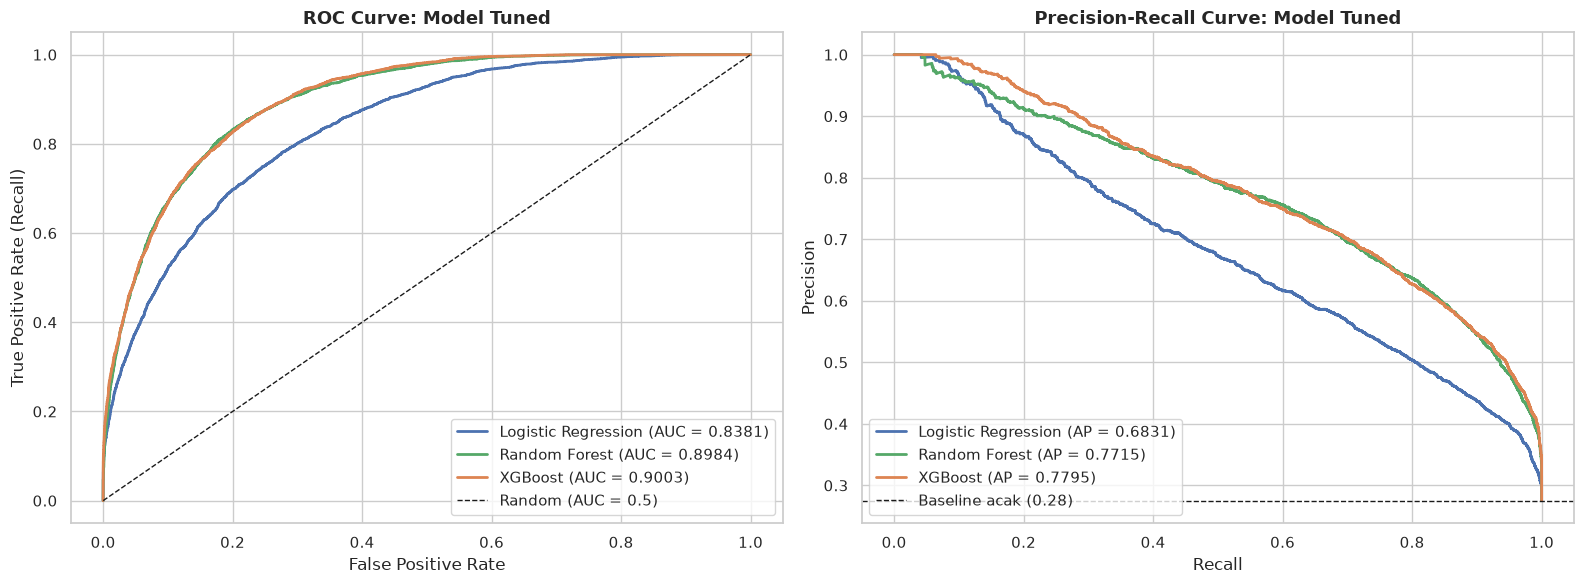

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = {'Logistic Regression': '#4c72b0', 'Random Forest': '#55a868', 'XGBoost': '#dd8452'}

for name, pipe in tuned_models.items():
    proba = pipe.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[0].plot(fpr, tpr, color=palette[name], linewidth=2,
                 label=f'{name} (AUC = {roc_auc_score(y_test, proba):.4f})')
    axes[1].plot(rec, prec, color=palette[name], linewidth=2,
                 label=f'{name} (AP = {average_precision_score(y_test, proba):.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
axes[0].set_title('ROC Curve: Model Tuned', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].legend(loc='lower right')

axes[1].axhline(y_test.mean(), color='k', linestyle='--', linewidth=1, label=f'Baseline acak ({y_test.mean():.2f})')
axes[1].set_title('Precision-Recall Curve: Model Tuned', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

**Confusion Matrix Model Tuned**

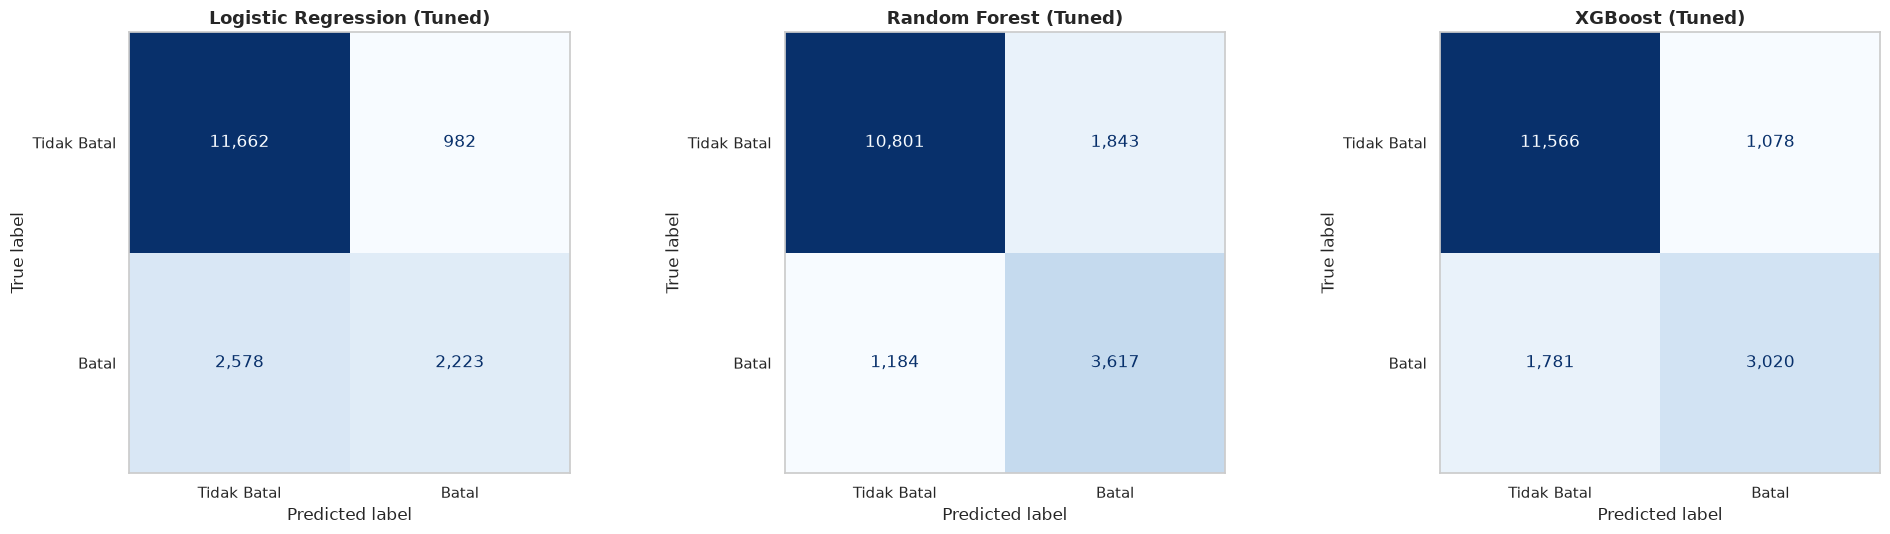

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
for ax, (name, pipe) in zip(axes, tuned_models.items()):
    ConfusionMatrixDisplay.from_estimator(
        pipe, x_test, y_test, display_labels=['Tidak Batal', 'Batal'],
        cmap='Blues', values_format=',', ax=ax, colorbar=False
    )
    ax.set_title(f'{name} (Tuned)', fontsize=13, fontweight='bold')
    ax.grid(False)
plt.tight_layout()
plt.show()

**Pemilihan Model Terbaik & Classification Report**

In [50]:
# Model terbaik dipilih dari CV ROC-AUC (data train), bukan dari data test, agar data test tetap independen
best_name  = max(tuned_models, key=lambda n: cv_tuned[n]['test_roc_auc'].mean())
best_model = tuned_models[best_name]
print(f"Model terbaik berdasarkan CV ROC-AUC (5-fold): {best_name}\n")
print(classification_report(y_test, best_model.predict(x_test), target_names=['Tidak Batal', 'Batal'], digits=4))

Model terbaik berdasarkan CV ROC-AUC (5-fold): XGBoost

              precision    recall  f1-score   support

 Tidak Batal     0.8666    0.9147    0.8900     12644
       Batal     0.7369    0.6290    0.6787      4801

    accuracy                         0.8361     17445
   macro avg     0.8018    0.7719    0.7844     17445
weighted avg     0.8309    0.8361    0.8319     17445



**Analisis Threshold**

Secara default, booking diprediksi batal jika probabilitas >= 0.5. Threshold dapat digeser sesuai kebutuhan
bisnis: threshold lebih rendah menangkap lebih banyak pembatalan (recall naik) dengan konsekuensi lebih banyak
false alarm (precision turun). Tabel berikut membantu memilih threshold yang sesuai.

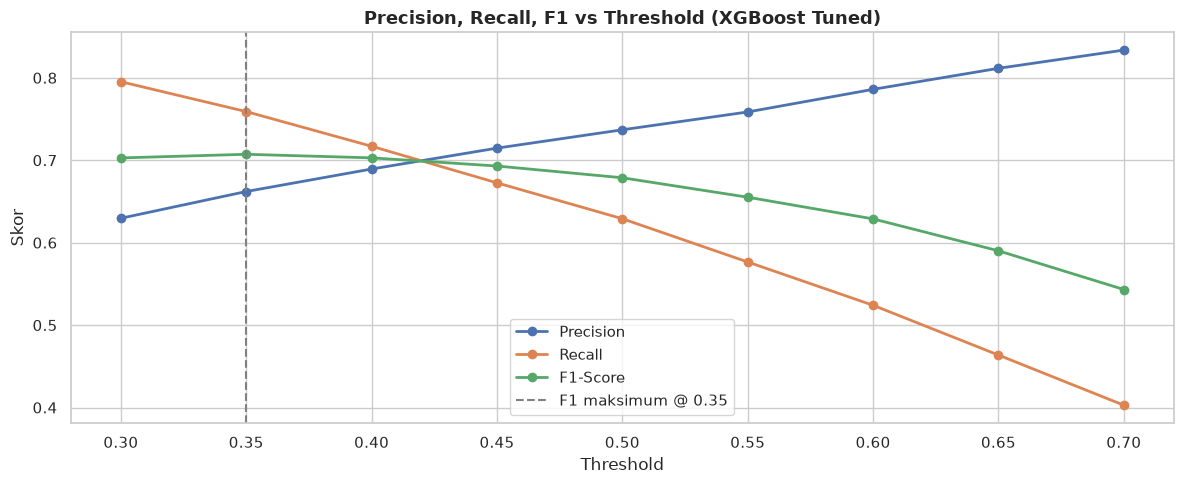

,Precision,Recall,F1-Score
Threshold,,,
0.30,0.6296,0.7953,0.7028
0.35,0.6621,0.7590,0.7072
0.40,0.6894,0.7169,0.7029
0.45,0.7147,0.6726,0.6930
0.50,0.7369,0.6290,0.6787
0.55,0.7586,0.5765,0.6551
0.60,0.7860,0.5241,0.6288
0.65,0.8115,0.4637,0.5901
0.70,0.8336,0.4028,0.5432


In [51]:
best_proba = best_model.predict_proba(x_test)[:, 1]
thr_rows = []
for thr in np.arange(0.3, 0.71, 0.05):
    pred = (best_proba >= thr).astype(int)
    thr_rows.append({'Threshold': round(thr, 2),
                     'Precision': precision_score(y_test, pred),
                     'Recall'   : recall_score(y_test, pred),
                     'F1-Score' : f1_score(y_test, pred)})
thr_df = pd.DataFrame(thr_rows).set_index('Threshold')

ax = thr_df.plot(figsize=(12, 5), marker='o', linewidth=2)
ax.axvline(thr_df['F1-Score'].idxmax(), color='gray', linestyle='--',
           label=f"F1 maksimum @ {thr_df['F1-Score'].idxmax():.2f}")
ax.set_title(f'Precision, Recall, F1 vs Threshold ({best_name} Tuned)', fontsize=13, fontweight='bold')
ax.set_ylabel('Skor')
ax.legend()
plt.tight_layout()
plt.show()
thr_df.round(4)

**Feature Importance Model Terbaik (Tuned)**

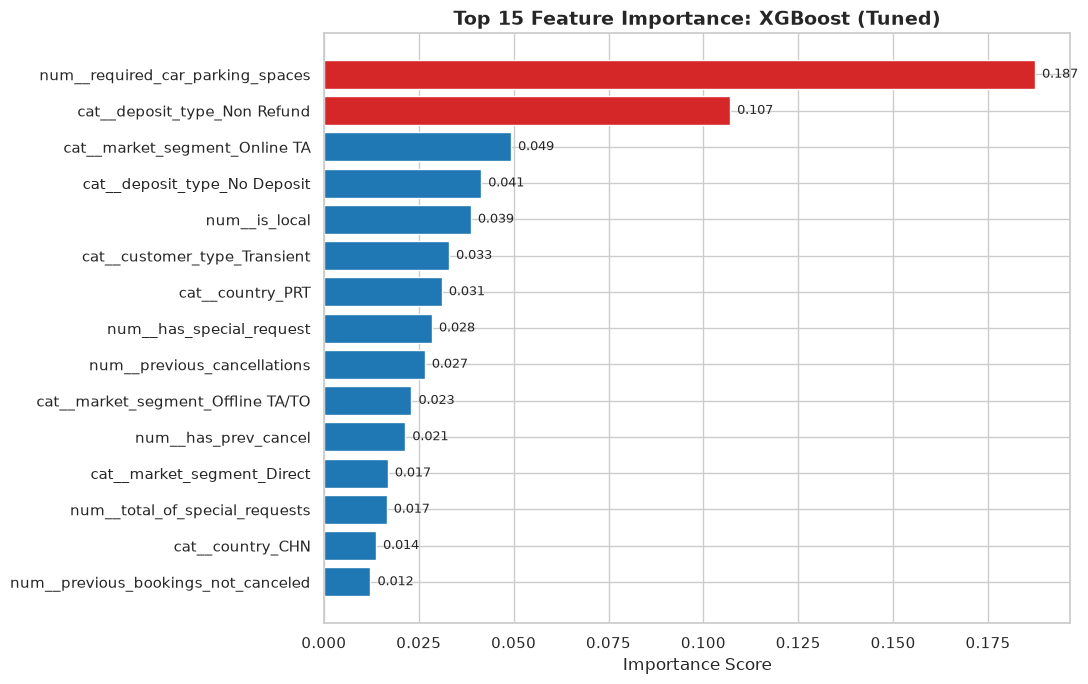

In [52]:
imp_best = pd.Series(best_model.named_steps['model'].feature_importances_
                     if hasattr(best_model.named_steps['model'], 'feature_importances_')
                     else np.abs(best_model.named_steps['model'].coef_[0]),
                     index=best_model.named_steps['prep'].get_feature_names_out())
top_15 = imp_best.nlargest(15).sort_values()

plt.figure(figsize=(11, 7))
colors = ['#d62728' if v >= top_15.max() * 0.5 else '#1f77b4' for v in top_15.values]
bars = plt.barh(top_15.index, top_15.values, color=colors, edgecolor='white')
for bar, val in zip(bars, top_15.values):
    plt.text(val + top_15.max() * 0.01, bar.get_y() + bar.get_height() / 2, f'{val:.3f}', va='center', fontsize=9)
plt.title(f'Top 15 Feature Importance: {best_name} (Tuned)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

**Ringkasan Evaluasi**

In [53]:
final_summary = test_comparison.xs('Tuned', level='Versi').copy()
final_summary['CV ROC-AUC (Tuned)'] = [cv_tuned[n]['test_roc_auc'].mean() for n in final_summary.index]
final_summary['Peningkatan ROC-AUC vs Baseline'] = [
    tuned_results[n]['ROC-AUC'] - baseline_results[n]['ROC-AUC'] for n in final_summary.index]
final_summary = final_summary.sort_values('ROC-AUC', ascending=False)
final_summary.round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV ROC-AUC (Tuned),Peningkatan ROC-AUC vs Baseline
Model,,,,,,,
XGBoost,0.8361,0.7369,0.6290,0.6787,0.9003,0.8966,0.0068
Random Forest,0.8265,0.6625,0.7534,0.7050,0.8984,0.8952,0.0077
Logistic Regression,0.7959,0.6936,0.4630,0.5553,0.8381,0.8372,0.0002


### Kesimpulan Evaluasi

- **Logistic Regression** menjadi batas bawah performa. Karena hubungan fitur dan pembatalan bersifat
  non-linear, model linear ini tertinggal cukup jauh dari model tree, dan tuning hanya memberi sedikit peningkatan.
- **Random Forest** dan **XGBoost** memberikan performa yang jauh lebih baik. Tuning membantu mengurangi
  overfitting Random Forest baseline dan meningkatkan kapasitas XGBoost (lebih banyak tree dengan learning rate lebih kecil).
- Model terbaik dipilih berdasarkan **CV ROC-AUC** pada data train, lalu dikonfirmasi pada data test. Selisih
  ROC-AUC Random Forest tuned dan XGBoost tuned sangat tipis, sehingga keduanya layak dipakai.
- Random Forest tuned memakai `class_weight='balanced'`, sehingga recall kelas batal lebih tinggi dengan precision
  lebih rendah. XGBoost tuned lebih seimbang dengan precision lebih tinggi. Pilihan akhir bergantung pada biaya
  bisnis: jika melewatkan pembatalan lebih mahal daripada false alarm, prioritaskan recall (atau turunkan threshold).

### Insight Bisnis

1. **Lead time** adalah prediktor terkuat. Booking yang dibuat jauh hari perlu dipantau, misalnya dengan
   reminder konfirmasi atau kebijakan deposit bertahap.
2. **Special request** dan **permintaan parkir** adalah sinyal komitmen tamu; booking tanpa keduanya lebih berisiko.
3. **Deposit type Non Refund** dan segmen **Groups / Online TA** memiliki cancellation rate tinggi. Perlu evaluasi
   kontrak dengan agen/grup (misalnya batas pembatalan atau release date yang lebih ketat).
4. **Tamu lokal (Portugal)** dan tamu dengan **riwayat pembatalan** lebih sering membatalkan.
5. Probabilitas dari model dapat dipakai untuk **overbooking yang terukur**: hotel dapat memperkirakan jumlah
   kamar yang kemungkinan batal per tanggal dan menyesuaikan kapasitas jual.

### Keterbatasan

- Dataset hanya mencakup 2015 - 2017 dari dua hotel di Portugal; perlu validasi ulang pada data terbaru.
- Pola `deposit_type = Non Refund` yang berlawanan intuisi kemungkinan dipengaruhi cara pencatatan data grup,
  sehingga perlu dikonfirmasi dengan tim operasional.

# **10. Deployment**

Pipeline model terbaik (preprocessor + model) disimpan dengan `joblib`, sehingga data booking baru cukup
diberikan dalam format mentah (setelah feature engineering yang sama) untuk mendapatkan prediksi.

In [54]:
def build_features(booking_df):
    """Menerapkan feature engineering yang sama seperti saat training pada data booking mentah."""
    d = booking_df.copy()
    d['children']            = d['children'].fillna(0)
    d['country']             = d['country'].fillna('Unknown')
    d['has_agent']           = d['agent'].notna().astype(int) if 'agent' in d else 0
    d['has_company']         = d['company'].notna().astype(int) if 'company' in d else 0
    d['meal']                = d['meal'].replace('Undefined', 'SC')
    month_num                = d['arrival_date_month'].map(month_map)
    arrival                  = pd.to_datetime(dict(year=d['arrival_date_year'], month=month_num,
                                                   day=d['arrival_date_day_of_month']))
    d['total_nights']        = d['stays_in_weekend_nights'] + d['stays_in_week_nights']
    d['total_guests']        = d['adults'] + d['children'] + d['babies']
    d['is_family']           = ((d['children'] + d['babies']) > 0).astype(int)
    d['total_cost']          = d['adr'] * d['total_nights']
    d['arrival_weekday']     = arrival.dt.weekday
    d['is_local']            = (d['country'] == 'PRT').astype(int)
    d['has_special_request'] = (d['total_of_special_requests'] > 0).astype(int)
    d['has_prev_cancel']     = (d['previous_cancellations'] > 0).astype(int)
    d['month_sin']           = np.sin(2 * np.pi * month_num / 12)
    d['month_cos']           = np.cos(2 * np.pi * month_num / 12)
    return d[feature_cols]

joblib.dump({'pipeline': best_model, 'feature_cols': feature_cols, 'model_name': best_name},
            'model_pipeline.pkl', compress=3)
print(f"Pipeline '{best_name}' tersimpan ke model_pipeline.pkl")

Pipeline 'XGBoost' tersimpan ke model_pipeline.pkl


In [55]:
def predict_cancellation(booking, threshold=0.5):
    try:
        artifact = joblib.load('model_pipeline.pkl')
    except FileNotFoundError:
        return 'Error: model_pipeline.pkl tidak ditemukan!'

    df_input = pd.DataFrame([booking]) if isinstance(booking, dict) else pd.DataFrame(booking)
    proba = artifact['pipeline'].predict_proba(build_features(df_input))[:, 1]
    return pd.DataFrame({
        'probabilitas_batal': proba.round(4),
        'prediksi'          : np.where(proba >= threshold, 'Batal', 'Tidak Batal'),
    })

In [56]:
booking_baru = [
    {   # Booking jauh hari lewat Online TA, tanpa special request
        'hotel': 'City Hotel', 'lead_time': 250, 'arrival_date_year': 2017, 'arrival_date_month': 'August',
        'arrival_date_week_number': 33, 'arrival_date_day_of_month': 15, 'stays_in_weekend_nights': 1,
        'stays_in_week_nights': 3, 'adults': 2, 'children': 0, 'babies': 0, 'meal': 'BB', 'country': 'PRT',
        'market_segment': 'Online TA', 'distribution_channel': 'TA/TO', 'is_repeated_guest': 0,
        'previous_cancellations': 0, 'previous_bookings_not_canceled': 0, 'reserved_room_type': 'A',
        'booking_changes': 0, 'deposit_type': 'No Deposit', 'agent': 9.0, 'company': np.nan,
        'days_in_waiting_list': 0, 'customer_type': 'Transient', 'adr': 120.0,
        'required_car_parking_spaces': 0, 'total_of_special_requests': 0,
    },
    {   # Tamu berulang, booking dekat hari H, dengan parkir dan special request
        'hotel': 'Resort Hotel', 'lead_time': 10, 'arrival_date_year': 2017, 'arrival_date_month': 'March',
        'arrival_date_week_number': 11, 'arrival_date_day_of_month': 12, 'stays_in_weekend_nights': 2,
        'stays_in_week_nights': 2, 'adults': 2, 'children': 1, 'babies': 0, 'meal': 'HB', 'country': 'GBR',
        'market_segment': 'Direct', 'distribution_channel': 'Direct', 'is_repeated_guest': 1,
        'previous_cancellations': 0, 'previous_bookings_not_canceled': 2, 'reserved_room_type': 'D',
        'booking_changes': 1, 'deposit_type': 'No Deposit', 'agent': np.nan, 'company': np.nan,
        'days_in_waiting_list': 0, 'customer_type': 'Transient', 'adr': 95.0,
        'required_car_parking_spaces': 1, 'total_of_special_requests': 2,
    },
]

predict_cancellation(booking_baru)

,probabilitas_batal,prediksi
0,0.8766,Batal
1,0.0001,Tidak Batal
